#**Pre-request**

##Mount google drive


In [1]:
### **Mount** Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##Install pakages


In [2]:
#Install pakages
project_path = "/content/drive/MyDrive/Sem-6/coding/github/fraud_detection/"
!cat "{project_path}requirement/Install/NASEnhancedPretraindMLModleAdvance.txt"
!pip install  -r "{project_path}requirement/Install/NASEnhancedPretraindMLModleAdvance.txt" --no-cache-dir
%cd $project_path





torch
transformers
huggingface_hub
datasets
timm
patool
sktime
reformer_pytorch
optuna
ptflopsRequirement already satisfied: torch in /usr/local/lib/python3.12/dist-packages (from -r /content/drive/MyDrive/Sem-6/coding/github/fraud_detection/requirement/Install/NASEnhancedPretraindMLModleAdvance.txt (line 1)) (2.11.0+cu128)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.4/101.4 kB 310.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.5/37.5 MB 339.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 387.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 375.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.3/165.3 kB 344.7 MB/s eta 0:00:00
/content/drive/MyDrive/Sem-6/coding/github/fraud_detection


##Import  libs

In [3]:
# =====================================================
# 📦 Standard Library
# =====================================================
import os
import sys
import time
import logging
import hashlib
import shutil
import subprocess
import warnings
from datetime import datetime

# Start timer
start_time = time.time()

# =====================================================
# 🧮 Data & Visualization
# =====================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

# Pandas display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

# =====================================================
# ⚙️ Machine Learning - Scikit-learn
# =====================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, RobustScaler, StandardScaler
from sklearn.utils import class_weight
from sklearn.covariance import EmpiricalCovariance
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

# =====================================================
# 🌲 XGBoost
# =====================================================
from xgboost import XGBClassifier
import joblib

# =====================================================
# 🔥 Deep Learning - PyTorch
# =====================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torch.cuda.amp import autocast

# =====================================================
# 🤖 Deep Learning - TensorFlow / Keras
# =====================================================
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Masking, Dropout, Layer
from tensorflow.keras.optimizers import Adam

# =====================================================
# 🤗 Transformers & Time Series
# =====================================================
from transformers import AutoModel
from sktime.datasets import load_from_tsfile_to_dataframe
# from mamba_ssm import Mamba  # Uncomment if needed

# =====================================================
# 🧠 Explainability
# =====================================================
import shap

# =====================================================
# 📊 Google Colab Specific
# =====================================================
from google.colab import data_table
data_table.enable_dataframe_formatter()
try:
    from google.colab import data_table
    data_table.enable_dataframe_formatter()
    data_table.DataTable.max_columns = 50
    data_table.DataTable.max_rows = 150
except ImportError:
    pass

from tqdm import tqdm

print("✅ All imports loaded successfully!")

✅ All imports loaded successfully!


##Confirmation setup

In [4]:
# =====================================================
# 🎲 Random Seeds (Reproducibility)
# =====================================================
!nvidia-smi                # confirm GPU
!pip show torch  # confirm versions
torch.manual_seed(42)
np.random.seed(42)

Thu Jul  9 12:35:14 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   32C    P0             54W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## Enable Config

In [5]:

logger = logging.getLogger(__name__)

def load_config(config_path="configs/baseline.yaml"):
    """Load YAML config file and expand ${root_path} placeholders."""
    with open(config_path, "r") as f:
        config = yaml.safe_load(f)

    logger.info(f"✅ Loaded config from {config_path}")

    # --- Expand ${root_path} placeholders ---
    root = config.get("root_path", "")

    def expand_paths(obj):
        if isinstance(obj, dict):
            return {k: expand_paths(v) for k, v in obj.items()}
        elif isinstance(obj, list):
            return [expand_paths(i) for i in obj]
        elif isinstance(obj, str) and "${root_path}" in obj:
            return obj.replace("${root_path}", root)
        else:
            return obj

    config = expand_paths(config)
    return config
config = load_config(os.path.join(project_path, "configs", "baseline.yaml"))


## Set Variables

In [6]:


#limit = config['ML']['limit']
n_trials=100

# ==========================================================
# UNIFIED HYPERPARAMETERS (Match TimesNet NAS Best)
# ==========================================================
# ==========================================================
# 🔧 UNIFIED HYPERPARAMETERS (Match TimesNet NAS Best)
# ==========================================================

# ----------------------------------------------------------
# 📏 Sequence Settings
# ----------------------------------------------------------
max_seq_len = 16                  # Maximum sequence length
recent_mode = False               # False → oldest mode, True → recent-window mode

# ----------------------------------------------------------
# 🏗️ Model Architecture (Shared across LSTM/Transformer/TimesNet)
# ----------------------------------------------------------
learning_rate = 0.000264431691667355          # Learning rate (RAdam)
d_model = 4                      # Model dimension
d_ff = 8                        # Feed-forward dimension
n_layers = 2                      # Number of layers (e_layers)
top_k=2
dropout = 0.150869531707295                   # Dropout rate
batch_size = 8                   # Batch size
patience = 3                      # Early stopping patience
#----------------------------------
RF_n_estimators=452
RF_max_depth=20
RF_min_samples_split=8
RF_min_samples_leaf=5

XGB_n_estimators= 381
XGB_max_depth= 7
XGB_learning_rate= 0.005603894398670345
XGB_subsample= 0.5139458956707923
XGB_colsample_bytree= 0.7759504431865178
XGB_min_child_weight= 2
XGB_gamma= 0.41564957017887644
XGB_scale_pos_weight=1.0


random_state=42
n_jobs=-1
eval_metric='auc'

#-----------------
activation = 'gelu'               # Activation function
n_heads = 2                       # Attention heads (Transformer only)
num_classes = 2                   # Binary classification
epochs = 20                       # Maximum training epochs
grad_clip_norm = 4.0              # Gradient clipping max norm
use_class_weights = False         # Whether to use class weights

# ----------------------------------------------------------
# 📊 Evaluation Settings
# ----------------------------------------------------------
opt_metric = "f1"                 # Optimization metric for model selection
correlation_threshold = 0.85      # Feature correlation threshold

# ----------------------------------------------------------
# 📈 Progressive Evaluation
# ----------------------------------------------------------
method = "linear"                 # Interpolation method for key_rounds
n_points = 10                     # Number of evaluation points

# ----------------------------------------------------------
# 💾 Paths
# ----------------------------------------------------------
model_path = config['ML']['models']

# ==========================================================
# ✅ Configuration Summary
# ==========================================================
print("="*60)
print("📋 CONFIGURATION SUMMARY")
print("="*60)
print(f"  Sequence length:  {max_seq_len}")
print(f"  Mode:             {'Recent' if recent_mode else 'Oldest'}")
print(f"  Architecture:     d_model={d_model}, d_ff={d_ff}, layers={n_layers}")
print(f"  Training:         epochs={epochs}, patience={patience}, lr={learning_rate}")
print(f"  Batch size:       {batch_size}")
print(f"  Dropout:          {dropout}")
print(f"  Model path:       {model_path}")
print("="*60)

# Global unified results table for all models
results_table = pd.DataFrame(columns=["Round", "AUC", "Recall", "F1", "Model"])
summary = pd.DataFrame(
    columns=[
        "Model",
        "AUC",
        "Recall",
        "Precision",
        "F1",
        "threshold"
    ]
)


📋 CONFIGURATION SUMMARY
  Sequence length:  16
  Mode:             Oldest
  Architecture:     d_model=4, d_ff=8, layers=2
  Training:         epochs=20, patience=3, lr=0.000264431691667355
  Batch size:       8
  Dropout:          0.150869531707295
  Model path:       /content/drive/MyDrive/Sem-6/coding/github/fraud_detection/models/


##Split users level

In [7]:

# user_path = config['ML']['Events']['base_path'] + config['ML']['Events']['files']['user']
# df_user = pd.read_csv(user_path)
# print(f"✅ Loaded transactional user dataset: {df_user.shape}")



# # Aggregate to one row per user (max label = 1 if any fraud)
# user_labels = df_user.groupby("phone_no_m")["label"].max()
# print(f"👥 Unique users for splitting: {len(user_labels)}")

# # ==============================================================
# # 2️⃣ Create user-level split (stratified, no leakage)
# # ==============================================================

# fraud_users = user_labels[user_labels == 1].index
# normal_users = user_labels[user_labels == 0].index

# fraud_train, fraud_test = train_test_split(fraud_users, test_size=0.2, random_state=42)
# normal_train, normal_test = train_test_split(normal_users, test_size=0.2, random_state=42)

# train_users = set(fraud_train) | set(normal_train)
# test_users  = set(fraud_test)  | set(normal_test)

# # ==============================================================
# # 3️⃣ Save unified split (shared across LSTM / RF / XGB)
# # ==============================================================

# split_dir = "splits"
# os.makedirs(split_dir, exist_ok=True)

# pd.DataFrame({"phone_no_m": sorted(train_users)}).to_csv(f"{split_dir}/train_users.csv", index=False)
# pd.DataFrame({"phone_no_m": sorted(test_users)}).to_csv(f"{split_dir}/test_users.csv", index=False)

# # ==============================================================
# # 4️⃣ Summary
# # ==============================================================

# print("\n👥 Users Summary:")
# print(f"   Total : {len(user_labels):,}")
# print(f"   Fraud : {len(fraud_users):,} ({len(fraud_users)/len(user_labels)*100:.2f}%)")
# print(f"   Normal: {len(normal_users):,} ({len(normal_users)/len(user_labels)*100:.2f}%)")

# print("\n📂 Split saved to /splits/:")
# print(f"   Train users: {len(train_users)}")
# print(f"   Test  users: {len(test_users)}")
# print(f"   Fraud ratio train: {len(fraud_train)/len(train_users)*100:.2f}%")
# print(f"   Fraud ratio test : {len(fraud_test)/len(test_users)*100:.2f}%")


## Helpers

### evaluate_global

In [8]:
def evaluate_global(model, X_test, y_test, model_name="Model", threshold=0.5):
    """
    Generic evaluator for both classic ML models and neural networks.
    """
    print(f"\n📊 Evaluation threshold is: {threshold}")

    # ---- Predict probabilities ----
    if hasattr(model, "predict_proba"):
        # For sklearn-style models
        y_pred_prob = model.predict_proba(X_test)[:, 1]
    else:
        # For neural nets (e.g., Keras)
        preds = model.predict(X_test)
        if preds.shape[-1] == 2:
            # 2-class softmax output
            y_pred_prob = preds[:, 1]
        else:
            # Single sigmoid output
            y_pred_prob = preds.ravel()

    # ... rest of function unchanged
    # ---- Predict classes ----
    y_pred = (y_pred_prob > threshold).astype(int)

    # ---- Metrics ----
    auc = roc_auc_score(y_test, y_pred_prob)
    #recall = recall_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred, zero_division=0)

    precision = precision_score(y_test, y_pred, zero_division=0)
    #f1 = f1_score(y_test, y_pred)
    f1     = f1_score(y_test, y_pred, zero_division=0)

    report = classification_report(y_test, y_pred, digits=4)
    cm = confusion_matrix(y_test, y_pred)

    # ---- Display ----
    print(f"\n📊 Classification Report — {model_name}")
    print(report)
    print(f"AUC: {auc:.4f} | Recall: {recall:.4f} | Precision: {precision:.4f} | F1: {f1:.4f}")

    # ---- Confusion Matrix ----
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal (0)", "Fraud (1)"])
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix — {model_name}")
    plt.grid(False)
    plt.show()

    # ---- Summary Dictionary ----
    return {
        "Model": model_name,
        "AUC": auc,
        "Recall": recall,
        "Precision": precision,
        "F1": f1,
        "threshold": threshold
    }



### append_to_summary

In [9]:

def append_to_summary(summary, model_name, results):
    """
    Appends or updates the summary table with model results.
    Works with both capitalized and lowercase keys automatically.
    """
    # ✅ Create summary DataFrame if missing
    if summary is None or not isinstance(summary, pd.DataFrame):
          summary = pd.DataFrame(columns=["Model", "AUC", "Recall", "Precision", "F1", "Threshold"])
    # Ensure "Model" column exists (prevents KeyError)
    if "Model" not in summary.columns:
        summary = pd.DataFrame(columns=["Model", "AUC", "Recall", "Precision", "F1", "Threshold"])

    # ✅ Normalize key names to lowercase
    results = {k.lower(): v for k, v in results.items()}

    # ✅ Remove any existing row for the same model
    summary = summary[summary["Model"] != model_name]

    # ✅ Add new row (robust to missing values)
    row = {
        "Model": model_name,
        "AUC": round(results.get("auc", np.nan), 4) if not pd.isna(results.get("auc", np.nan)) else np.nan,
        "Recall": round(results.get("recall", np.nan), 4) if not pd.isna(results.get("recall", np.nan)) else np.nan,
        "Precision": round(results.get("precision", np.nan), 4) if not pd.isna(results.get("precision", np.nan)) else np.nan,
        "F1": round(results.get("f1", np.nan), 4) if not pd.isna(results.get("f1", np.nan)) else np.nan,
        "Threshold": round(results.get("threshold", np.nan), 4) if not pd.isna(results.get("threshold", np.nan)) else np.nan
    }


    # ✅ Append and reindex
    summary = pd.concat([summary, pd.DataFrame([row])], ignore_index=True)
    summary = summary.reindex(columns=["Model", "AUC", "Recall", "Precision", "F1", "Threshold"])
    return summary


### find_best_threshold

In [10]:
def find_best_threshold(y_true, probs, low=0.2, high=0.8, n=61):
    best_f1 = -1.0
    best_thr = 0.5
    for thr in np.linspace(low, high, n):
        preds = (probs >= thr).astype(int)
        f1 = f1_score(y_true, preds, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thr = thr
    return best_thr, best_f1

###Drop and select features

In [11]:
def prepare_features(df):
    """
    Selects only the explicitly defined features for model training.
    You control which features are used by editing 'selected_features' below.
    """

    # --- Define selected features manually ---
    selected_features = [
        "window_size", "voc_total_calls", "voc_unique_contacts", "voc_total_duration",
       "voc_avg_duration", "voc_max_duration", "voc_std_duration", "voc_active_days",
       "voc_active_hours", "sms_total_msgs", "sms_unique_contacts", "sms_active_hours",
       "sms_calltype_ratio", "app_months_active", "app_total_flow", "app_avg_flow",
       "app_std_flow", "app_unique_apps_mean", "app_unique_apps_max", "user_months_active",
        "arpu_mean", "arpu_std", "arpu_max", "idcard_cnt", "snapshot_round"
   ]
  #  selected_features = [
   #     "voc_total_calls", "voc_unique_contacts", "voc_total_duration",
    #   "voc_avg_duration", "voc_max_duration", "voc_std_duration", "voc_active_days",
     # "voc_active_hours", "sms_total_msgs", "sms_unique_contacts", "sms_active_hours",
     #"sms_calltype_ratio", "idcard_cnt"
    #]
   # selected_features = [
    #    "voc_active_days",
    #"voc_active_hours",
    #"voc_unique_contacts",
    #"sms_calltype_ratio",
    #"sms_active_hours" ]


    # ✅ You can manually remove or comment out features here
    # For example:
    # selected_features = [f for f in selected_features if not (f.startswith("app_") or f.startswith("arpu_"))]

    # --- Keep only existing columns ---
    available = [f for f in selected_features if f in df.columns]
    missing = [f for f in selected_features if f not in df.columns]

    X = df[available].copy()

    #print(f"\n📊 Final features used ({len(available)}): {available}")
    if missing:
        print(f"⚠️ Missing columns not found in data: {missing}")

    return X


### Compare

In [12]:

def plot_progressive_results(
    results_table,
    metrics=("AUC", "Recall", "F1"),
    round_col=None,
    figsize=(14, 6)
):
    """
    Plot progressive evaluation metrics per round for multiple models.

    Parameters
    ----------
    results_table : pd.DataFrame
        Must contain columns: Model, metrics, and either Round or input_size
    metrics : tuple
        Metrics to plot (default: AUC, Recall, F1)
    round_col : str or None
        Column name for x-axis. If None, auto-detects.
    figsize : tuple
        Figure size for plots
    """

    # --------------------------------------------------
    # Auto-detect round column
    # --------------------------------------------------
    if round_col is None:
        if "Round" in results_table.columns:
            round_col = "Round"
        elif "input_size" in results_table.columns:
            round_col = "input_size"
        else:
            raise ValueError("No Round or input_size column found.")

    # --------------------------------------------------
    # Sort results (important for correct curves)
    # --------------------------------------------------
    results_table = results_table.sort_values(
        by=[round_col, "Model"],
        ascending=True
    ).reset_index(drop=True)


    # --------------------------------------------------
    # Plot each metric
    # --------------------------------------------------
    for metric in metrics:

        plt.figure(figsize=figsize)

        for model in results_table["Model"].unique():
            subset = (
                results_table[results_table["Model"] == model]
                .sort_values(by=round_col)
            )

            plt.plot(
                subset[round_col],
                subset[metric],
                marker="o",
                markersize=6,
                linewidth=2,
                label=model,
                alpha=0.85
            )

        plt.title(f"{metric} per {round_col}", fontsize=18)
        plt.xlabel(round_col, fontsize=14)
        plt.ylabel(metric, fontsize=14)
        plt.grid(True, linestyle="--", alpha=0.4)

        # Legend outside
        plt.legend(
            loc="upper center",
            bbox_to_anchor=(0.5, -0.12),
            ncol=4,
            fontsize=10
        )

        plt.tight_layout(rect=[0, 0.1, 1, 1])
        plt.show()
    display(results_table)

    return results_table


###get_key_rounds

In [13]:
# ============================================================
# 🔬 SCIENTIFIC KEY ROUNDS SELECTION
# ============================================================

def get_key_rounds(max_seq_len, method="linear", n_points=5):
    """
    Generate scientifically meaningful evaluation checkpoints.

    Args:
        max_seq_len: Maximum sequence length (16, 100, 300, etc.)
        method: Selection strategy
            - "linear": Equal spacing (1, 25%, 50%, 75%, 100%)
            - "logarithmic": More points early (where changes happen fast)
            - "sqrt": Square root spacing (balanced)
            - "percentile": Fixed percentages
        n_points: Number of evaluation points (default 5)

    Returns:
        List of round numbers to evaluate
    """

    if max_seq_len <= n_points:
        # If sequence is short, evaluate all rounds
        return list(range(1, max_seq_len + 1))

    if method == "linear":
        # Equal spacing: 1, 25%, 50%, 75%, 100%
        rounds = np.linspace(1, max_seq_len, n_points)

    elif method == "logarithmic":
        # More points early (fraud detection often shows early signal)
        # Log scale: 1, 2, 4, 8, 16 style
        rounds = np.logspace(0, np.log10(max_seq_len), n_points)

    elif method == "sqrt":
        # Square root spacing (balanced between linear and log)
        rounds = np.square(np.linspace(1, np.sqrt(max_seq_len), n_points))

    elif method == "percentile":
        # Fixed percentages: 1st event, 10%, 25%, 50%, 75%, 100%
        percentages = [0, 0.1, 0.25, 0.5, 0.75, 1.0]
        rounds = [max(1, int(p * max_seq_len)) for p in percentages]
        return sorted(set(rounds))  # Remove duplicates

    elif method == "early_focus":
        # Focus on early detection (more points in first half)
        # Useful for fraud detection where early signal matters
        early = np.linspace(1, max_seq_len * 0.5, n_points - 2)
        late = [max_seq_len * 0.75, max_seq_len]
        rounds = np.concatenate([early, late])

    else:
        raise ValueError(f"Unknown method: {method}")

    # Convert to integers, ensure valid range, remove duplicates
    rounds = [int(round(r)) for r in rounds]
    rounds = [max(1, min(r, max_seq_len)) for r in rounds]
    rounds = sorted(set(rounds))

    # Always include 1 and max_seq_len
    if 1 not in rounds:
        rounds = [1] + rounds
    if max_seq_len not in rounds:
        rounds = rounds + [max_seq_len]

    return rounds

key_rounds = get_key_rounds(max_seq_len, method=method, n_points=n_points)
print(f"📊 Evaluating rounds: {key_rounds}")
print(f"   Total: {len(key_rounds)} rounds instead of {max_seq_len}")

📊 Evaluating rounds: [1, 3, 4, 6, 8, 9, 11, 13, 14, 16]
   Total: 10 rounds instead of 16


#ML Modules

### Feature Importance

In [14]:
# def plot_feature_importance(model, X_train, model_name="Model", top_n=20):
#     """
#     Plot feature importance for tree-based models (XGBoost, RandomForest).
#     """


#     # Handle model type
#     if hasattr(model, "get_booster"):  # XGBoost
#         importance = model.get_booster().get_score(importance_type='gain')
#         fi = pd.DataFrame({
#             'Feature': list(importance.keys()),
#             'Importance': list(importance.values())
#         })
#     elif hasattr(model, "feature_importances_"):  # RandomForest
#         fi = pd.DataFrame({
#             'Feature': X_train.columns,
#             'Importance': model.feature_importances_
#         })
#     else:
#         raise ValueError(f"{model_name} does not support feature importance extraction.")

#     # Sort and plot
#     fi = fi.sort_values(by='Importance', ascending=False)
#     display(fi.head(10))

#     plt.figure(figsize=(10,6))
#     plt.barh(fi['Feature'][:top_n][::-1], fi['Importance'][:top_n][::-1])
#     plt.title(f'📊 {model_name} Feature Importance (Top {top_n})')
#     plt.xlabel('Importance')
#     plt.ylabel('Feature')
#     plt.grid(alpha=0.4)
#     plt.tight_layout()
#     plt.show()

#     return fi

# fi_xgb = plot_feature_importance(xgb_model, snap_X_train, "XGBoost")
# fi_rf = plot_feature_importance(rf_model, snap_X_train, "Random Forest")


### Load

In [15]:
def load_raw_datasets(config):


    if "ML" in config and "Events" in config["ML"]:
        events_cfg = config["ML"]["Events"]
    else:
        events_cfg = config["Events"]

    base = events_cfg["base_path"]
    files = events_cfg["files"]

    # --- Load all datasets ---
    df_voc = pd.read_csv(os.path.join(base, files["voc"]))
    df_sms = pd.read_csv(os.path.join(base, files["sms"]))
    df_app = pd.read_csv(os.path.join(base, files["app"]))
    df_user = pd.read_csv(os.path.join(base, files["user"]))

    # --- Normalize timestamps and add source column ---
    for df, src in [(df_voc, "VOC"), (df_sms, "SMS"), (df_app, "APP"), (df_user, "USER")]:
        df["source"] = src
        ts_col = [c for c in df.columns if "time" in c.lower()][0]
        df.rename(columns={ts_col: "event_time"}, inplace=True)
        df["event_time"] = pd.to_datetime(df["event_time"], errors="coerce")

    print("✅ Raw datasets loaded and timestamp-normalized.")
    return df_voc, df_sms, df_app, df_user

df_voc, df_sms, df_app, df_user = load_raw_datasets(config)


✅ Raw datasets loaded and timestamp-normalized.


### Build timeline (events)

In [16]:
def merge_and_prepare_events(df_voc, df_sms, df_app, df_user):

    # --- 1️⃣ Normalize USER dataset ---
    if 'label' not in df_user.columns:
        raise KeyError("❌ 'label' column not found in user dataset")

    # Ensure numeric consistency
    df_user['label'] = df_user['label'].fillna(0).astype(int)
    df_user['idcard_cnt'] = df_user['idcard_cnt'].fillna(0).astype(float)
    df_user['arpu_value'] = df_user['arpu_value'].fillna(0).astype(float)

    # --- 2️⃣ Extract static info for merging (label + sim count only) ---
    #static_user_info = df_user.groupby("phone_no_m", as_index=False)[["label", "idcard_cnt"]].max()
    # --- 2️⃣ Extract static info from the RAW user table (covers all 6,106 users) ---
    lbl_cfg = config["ML"]["labels"]
    raw_user = pd.read_csv(os.path.join(lbl_cfg["base_path"], lbl_cfg["file"]))
    static_user_info = raw_user[["phone_no_m", "label", "idcard_cnt"]].drop_duplicates("phone_no_m")
    static_user_info["label"] = static_user_info["label"].astype(int)
    static_user_info["idcard_cnt"] = static_user_info["idcard_cnt"].fillna(0).astype(float)

    # --- 3️⃣ Merge static info into other event tables ---
    df_voc = df_voc.merge(static_user_info, on="phone_no_m", how="left")
    df_sms = df_sms.merge(static_user_info, on="phone_no_m", how="left")
    df_app = df_app.merge(static_user_info, on="phone_no_m", how="left")


    # --- 4️⃣ Combine all transactional event sources ---
    # include df_user itself since arpu_value is event-like
    events = pd.concat([df_voc, df_sms, df_app, df_user], ignore_index=True)

    # --- 5️⃣ Fill and order ---
    #events["label"] = events["label"].fillna(0).astype(int)
    missing = int(events["label"].isna().sum())
    assert missing == 0, f"{missing} events have no label — label merge is broken"
    events["label"] = events["label"].astype(int)

    events["event_time"] = pd.to_datetime(events["event_time"], errors="coerce")
    events = events.sort_values(["phone_no_m", "event_time"]).reset_index(drop=True)

    # --- 6️⃣ Summary ---
    print("\n🔎 Feature Summary per Source:")
    for src, df in [("VOC", df_voc), ("SMS", df_sms), ("APP", df_app), ("USER", df_user)]:
        print(f"\n📂 Source: {src}")
        print(f"   Events: {len(df):,}")
        print(f"   Users : {df['phone_no_m'].nunique():,}")
        print(f"   Columns ({len(df.columns)}): {', '.join(df.columns)}")

    print("\n📊 Combined Dataset Summary:")
    print(f"   Total events: {len(events):,}")
    print(f"   Unique users: {events['phone_no_m'].nunique():,}")
    print(f"   Fraud ratio: {events['label'].mean()*100:.2f}%")
    user_labels = events.groupby("phone_no_m")["label"].max()
    print(f"   Fraud users: {int(user_labels.sum()):,} / {user_labels.size:,} ({user_labels.mean()*100:.2f}%)")

    return events

events = merge_and_prepare_events(df_voc, df_sms, df_app, df_user)

display(events.head())


🔎 Feature Summary per Source:

📂 Source: VOC
   Events: 5,015,430
   Users : 6,025
   Columns (11): phone_no_m, opposite_no_m, calltype_id, event_time, call_dur, city_name, county_name, imei_m, source, label, idcard_cnt

📂 Source: SMS
   Events: 6,848,509
   Users : 6,103
   Columns (7): phone_no_m, opposite_no_m, calltype_id, event_time, source, label, idcard_cnt

📂 Source: APP
   Events: 3,283,602
   Users : 6,106
   Columns (10): phone_no_m, event_time, source, busi_name, flow, month_id, flow_norm, month_str, label, idcard_cnt

📂 Source: USER
   Events: 39,454
   Users : 5,929
   Columns (10): phone_no_m, event_time, source, month_id, arpu_value, city_name, county_name, idcard_cnt, label, month_col

📊 Combined Dataset Summary:
   Total events: 15,186,995
   Unique users: 6,106
   Fraud ratio: 24.63%
   Fraud users: 1,962 / 6,106 (32.13%)


,phone_no_m,opposite_no_m,calltype_id,event_time,call_dur,city_name,county_name,imei_m,source,label,idcard_cnt,busi_name,flow,month_id,flow_norm,month_str,arpu_value,month_col
0,00073ceecc0f7220a440580ac5dea410c90d14b6669458...,df22edbc0e3dd6bc4f2f453e687b743e8442a54834b64f...,2.0,2019-08-12 08:09:11,NaN,NaN,NaN,NaN,SMS,0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,00073ceecc0f7220a440580ac5dea410c90d14b6669458...,df22edbc0e3dd6bc4f2f453e687b743e8442a54834b64f...,2.0,2019-08-12 08:09:11,NaN,NaN,NaN,NaN,SMS,0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,00073ceecc0f7220a440580ac5dea410c90d14b6669458...,df22edbc0e3dd6bc4f2f453e687b743e8442a54834b64f...,2.0,2019-08-12 08:09:11,NaN,NaN,NaN,NaN,SMS,0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,00073ceecc0f7220a440580ac5dea410c90d14b6669458...,df22edbc0e3dd6bc4f2f453e687b743e8442a54834b64f...,2.0,2019-08-13 16:21:53,NaN,NaN,NaN,NaN,SMS,0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,00073ceecc0f7220a440580ac5dea410c90d14b6669458...,df22edbc0e3dd6bc4f2f453e687b743e8442a54834b64f...,2.0,2019-08-13 16:21:53,NaN,NaN,NaN,NaN,SMS,0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Split data based on users (fraud, not fraud)

In [17]:


# ======================================
# Clean Numeric Columns
# ======================================
events = events.copy()
numeric_cols = events.select_dtypes(include=["number"]).columns.difference(["label"])

# Replace NaN with 0 for numeric fields (avoids scaling issues)
events[numeric_cols] = events[numeric_cols].fillna(0)

print(f"\n📊 Numeric columns to scale ({len(numeric_cols)}): {numeric_cols.tolist()}")


# ======================================
# 2 Create / Load Shared Train-Val-Test User Split
# ======================================
split_dir = os.path.join(config["root_path"], "splits", "shared_user_split_v1")
train_split_file = f"{split_dir}/train_users.csv"
test_split_file  = f"{split_dir}/test_users.csv"
val_split_file   = f"{split_dir}/val_users.csv"

os.makedirs(split_dir, exist_ok=True)

all_split_files_exist = (
    os.path.exists(train_split_file)
    and os.path.exists(test_split_file)
    and os.path.exists(val_split_file)
)

if all_split_files_exist:
    print("📂 Using shared user split files...")
    train_users = set(pd.read_csv(train_split_file)["phone_no_m"])
    test_users  = set(pd.read_csv(test_split_file)["phone_no_m"])
    val_users   = set(pd.read_csv(val_split_file)["phone_no_m"])
else:
    print("🆕 Creating shared train/test/val user split...")

    # One label per user
    user_labels = events.groupby("phone_no_m")["label"].max()
    fraud_users = user_labels[user_labels == 1].index
    normal_users = user_labels[user_labels == 0].index

    # 1) Train/Test split (split fraud user %)
    fraud_train, fraud_test = train_test_split(
        fraud_users, test_size=0.2, random_state=42
    )
    normal_train, normal_test = train_test_split(
        normal_users, test_size=0.2, random_state=42
    )

    train_users_full = set(fraud_train) | set(normal_train)
    test_users = set(fraud_test) | set(normal_test)

    # 2) Validation split from training users only
    train_user_labels = user_labels.loc[list(train_users_full)]

    fraud_train_users = train_user_labels[train_user_labels == 1].index
    normal_train_users = train_user_labels[train_user_labels == 0].index

    fraud_tr, fraud_val = train_test_split(
        fraud_train_users, test_size=0.2, random_state=42
    )
    normal_tr, normal_val = train_test_split(
        normal_train_users, test_size=0.2, random_state=42
    )

    train_users = set(fraud_tr) | set(normal_tr)
    val_users   = set(fraud_val) | set(normal_val)

    pd.DataFrame({"phone_no_m": sorted(train_users)}).to_csv(train_split_file, index=False)
    pd.DataFrame({"phone_no_m": sorted(test_users)}).to_csv(test_split_file, index=False)
    pd.DataFrame({"phone_no_m": sorted(val_users)}).to_csv(val_split_file, index=False)

    print(f"✅ Saved shared split files to '{split_dir}/'")
# ======================================
# Split overlap checks
# ======================================
assert len(train_users & test_users) == 0, "❌ User leakage: train and test overlap"
assert len(train_users & val_users) == 0, "❌ User leakage: train and val overlap"
assert len(test_users & val_users) == 0, "❌ User leakage: test and val overlap"

print("🔒 Split overlap checks passed:")
print(f"   train ∩ test = {len(train_users & test_users)}")
print(f"   train ∩ val  = {len(train_users & val_users)}")
print(f"   test  ∩ val  = {len(test_users & val_users)}")
user_labels = events.groupby("phone_no_m")["label"].max()
print(f"   sizes  train/val/test = {len(train_users)} / {len(val_users)} / {len(test_users)}")
print(f"   fraud  train/val/test = {int(user_labels.loc[list(train_users)].sum())} / "
      f"{int(user_labels.loc[list(val_users)].sum())} / {int(user_labels.loc[list(test_users)].sum())}")
# ======================================
# Apply Split to Events
# ======================================
train_events = events[events["phone_no_m"].isin(train_users)]
test_events  = events[events["phone_no_m"].isin(test_users)]
val_events = events[events["phone_no_m"].isin(val_users)]

# Sanity checks
assert len(set(train_events["phone_no_m"]) & set(test_events["phone_no_m"])) == 0, "❌ User leakage detected!"
assert train_events["label"].nunique() == 2, "❌ Training set must contain both classes"
assert test_events["label"].nunique() == 2, "❌ Test set must contain both classes"

# --- add time gap, scaled featur ---
# for name, df in [('train_events', train_events), ('test_events', test_events)]:
#     df = df.copy()  # avoid SettingWithCopyWarning
#     df['event_time'] = pd.to_datetime(df['event_time'])
#     #df.sort_values(['phone_no_m', 'event_time'], inplace=True)
#     df = df.sort_values(['phone_no_m', 'event_time'], kind='mergesort').reset_index(drop=True)
#     df['dt_hours'] = df.groupby('phone_no_m')['event_time'].diff().dt.total_seconds() / 3600
#     df['dt_hours'] = df['dt_hours'].fillna(0)
#     df['dt_hours'] = np.log1p(df['dt_hours'])  # normalize gaps
#     if name == 'train_events':
#         train_events = df
#     else:
#         test_events = df
for name, df in [
    ('train_events', train_events),
    ('val_events', val_events),
    ('test_events', test_events)
]:
    df = df.copy()
    df['event_time'] = pd.to_datetime(df['event_time'])
    df = df.sort_values(['phone_no_m', 'event_time'], kind='mergesort').reset_index(drop=True)
    df['dt_hours'] = df.groupby('phone_no_m')['event_time'].diff().dt.total_seconds() / 3600
    df['dt_hours'] = df['dt_hours'].fillna(0)
    df['dt_hours'] = np.log1p(df['dt_hours'])

    if name == 'train_events':
        train_events = df
    elif name == 'val_events':
        val_events = df
    else:
        test_events = df


# Store unscaled events BEFORE line 895
train_events_unscaled = train_events.copy()
test_events_unscaled = test_events.copy()
val_events_unscaled = val_events.copy()


# Sanity checks
assert len(set(train_events["phone_no_m"]) & set(test_events["phone_no_m"])) == 0, "❌ User leakage detected!"
assert train_events["label"].nunique() == 2, "❌ Training set must contain both classes"
assert test_events["label"].nunique() == 2, "❌ Test set must contain both classes"
scale_cols_seq = sorted(set(train_events.select_dtypes(include=["number"]).columns) - {"label"})
scaler_seq = StandardScaler().fit(train_events[scale_cols_seq])
train_events[scale_cols_seq] = scaler_seq.transform(train_events[scale_cols_seq])
test_events[scale_cols_seq]  = scaler_seq.transform(test_events[scale_cols_seq])
val_events[scale_cols_seq]   = scaler_seq.transform(val_events[scale_cols_seq])

# ======================================
# 4️⃣ snapshot
# ======================================

# ======================================
# 4️⃣ Create Sequences (using multiple features)
# ======================================
numeric_features = [c for c in numeric_cols if c not in ["label"]]  # exclude label
if 'dt_hours' in train_events.columns:
    numeric_features.append('dt_hours')
print(f"\n📦 Features used for sequences: {numeric_features}")
feature_cols_tf = numeric_features.copy()
# 👉 Transformer feature columns: same numeric features as LSTM + source_id

if "source_id" not in feature_cols_tf:
    feature_cols_tf.append("source_id")

print("[Transformer] feature_cols_tf:", feature_cols_tf)



📊 Numeric columns to scale (6): ['arpu_value', 'call_dur', 'calltype_id', 'flow', 'flow_norm', 'idcard_cnt']
📂 Using shared user split files...
🔒 Split overlap checks passed:
   train ∩ test = 0
   train ∩ val  = 0
   test  ∩ val  = 0
   sizes  train/val/test = 3907 / 977 / 1222
   fraud  train/val/test = 1255 / 314 / 393

📦 Features used for sequences: ['arpu_value', 'call_dur', 'calltype_id', 'flow', 'flow_norm', 'idcard_cnt', 'dt_hours']
[Transformer] feature_cols_tf: ['arpu_value', 'call_dur', 'calltype_id', 'flow', 'flow_norm', 'idcard_cnt', 'dt_hours', 'source_id']


### Generate_snapshots_from_events

In [18]:
# ============================================================
# 🔧 OPTIMIZED SNAPSHOT GENERATION FROM EVENTS (FIXED)
# ============================================================

def generate_snapshots_from_events(
    events_df,
    users,
    r,
    max_seq_len,
    recent_mode=True
):
    """
    Generate snapshot features from events DataFrame.
    OPTIMIZED: Uses groupby instead of per-user filtering.
    """

    # 1️⃣ Filter to relevant users FIRST (huge speedup)
    events_filtered = events_df[events_df["phone_no_m"].isin(users)].copy()

    if events_filtered.empty:
        return pd.DataFrame(), np.array([]), np.array([])

    # 2️⃣ Sort once
    events_filtered = events_filtered.sort_values(["phone_no_m", "event_time"])

    # 3️⃣ Apply selection logic per user using groupby
    def select_events(df_u):
        if recent_mode:
            df_u = df_u.tail(max_seq_len).head(r)
        else:
            df_u = df_u.head(r)
        return df_u

    selected = events_filtered.groupby("phone_no_m", group_keys=False).apply(select_events)

    if selected.empty:
        return pd.DataFrame(), np.array([]), np.array([])

    # 4️⃣ Aggregate features using groupby
    snapshot_rows = []

    for user, df_u in tqdm(selected.groupby("phone_no_m"), desc="Generating snapshots"):
    #for user, df_u in selected.groupby("phone_no_m"):
        row = {"phone_no_m": user}

        # Get label
        label = int(df_u["label"].max()) if "label" in df_u.columns else 0

        # --- Voice Features ---
        voc = df_u[df_u["source"] == "VOC"]
        if len(voc) > 0:
            if "call_dur" in voc.columns:
                call_dur = pd.to_numeric(voc["call_dur"], errors="coerce").fillna(0)
            else:
                call_dur = pd.Series([0])

            row["voc_total_calls"] = len(voc)
            row["voc_unique_contacts"] = voc["opposite_no_m"].nunique() if "opposite_no_m" in voc.columns else 0
            row["voc_total_duration"] = call_dur.sum()
            row["voc_avg_duration"] = call_dur.mean()
            row["voc_max_duration"] = call_dur.max()
            row["voc_std_duration"] = call_dur.std() if len(call_dur) > 1 else 0
            row["voc_active_days"] = voc["event_time"].dt.weekday.nunique()
            row["voc_active_hours"] = voc["event_time"].dt.hour.nunique()
        else:
            row.update({
                "voc_total_calls": 0, "voc_unique_contacts": 0, "voc_total_duration": 0,
                "voc_avg_duration": 0, "voc_max_duration": 0, "voc_std_duration": 0,
                "voc_active_days": 0, "voc_active_hours": 0
            })

        # --- SMS Features ---
        sms = df_u[df_u["source"] == "SMS"]
        if len(sms) > 0:
            row["sms_total_msgs"] = len(sms)
            row["sms_unique_contacts"] = sms["opposite_no_m"].nunique() if "opposite_no_m" in sms.columns else 0
            row["sms_active_hours"] = sms["event_time"].dt.hour.nunique()
            if "calltype_id" in sms.columns:
                calltype = pd.to_numeric(sms["calltype_id"], errors="coerce")
                row["sms_calltype_ratio"] = (calltype == 1).mean()
            else:
                row["sms_calltype_ratio"] = 0
        else:
            row.update({
                "sms_total_msgs": 0, "sms_unique_contacts": 0,
                "sms_active_hours": 0, "sms_calltype_ratio": 0
            })

        # --- App Features ---
        app = df_u[df_u["source"] == "APP"]
        if len(app) > 0:
            if "flow" in app.columns:
                flow = pd.to_numeric(app["flow"], errors="coerce").fillna(0)
            else:
                flow = pd.Series([0])

            row["app_months_active"] = app["month_id"].nunique() if "month_id" in app.columns else 0
            row["app_total_flow"] = flow.sum()
            row["app_avg_flow"] = flow.mean()
            row["app_std_flow"] = flow.std() if len(flow) > 1 else 0
            row["app_unique_apps_mean"] = app["busi_name"].nunique() if "busi_name" in app.columns else 0
            row["app_unique_apps_max"] = app["busi_name"].nunique() if "busi_name" in app.columns else 0
        else:
            row.update({
                "app_months_active": 0, "app_total_flow": 0, "app_avg_flow": 0,
                "app_std_flow": 0, "app_unique_apps_mean": 0, "app_unique_apps_max": 0
            })

        # --- User/ARPU Features ---
        arpu = df_u[df_u["source"] == "USER"]
        if len(arpu) > 0:
            if "arpu_value" in arpu.columns:
                arpu_val = pd.to_numeric(arpu["arpu_value"], errors="coerce")
            else:
                arpu_val = pd.Series([0])

            row["user_months_active"] = arpu["month_id"].nunique() if "month_id" in arpu.columns else 0
            row["arpu_mean"] = arpu_val.mean()
            row["arpu_std"] = arpu_val.std() if len(arpu_val) > 1 else 0
            row["arpu_max"] = arpu_val.max()
            row["idcard_cnt"] = arpu["idcard_cnt"].max() if "idcard_cnt" in arpu.columns else 0
        else:
            row.update({
                "user_months_active": 0, "arpu_mean": 0, "arpu_std": 0,
                "arpu_max": 0, "idcard_cnt": 0
            })

        # Meta features
        row["window_size"] = r
        row["snapshot_round"] = r
        row["label"] = label

        snapshot_rows.append(row)

    # Build DataFrame
    df_snapshot = pd.DataFrame(snapshot_rows).fillna(0)

    if df_snapshot.empty:
        return pd.DataFrame(), np.array([]), np.array([])

    y = df_snapshot["label"].values
    user_ids = df_snapshot["phone_no_m"].values
    X = df_snapshot.drop(columns=["phone_no_m", "label"])

    return X, y, user_ids



#  ▶ Classic Ml Snapshot based

###### Genrate input data

In [19]:

# ============================================================
# 📋 Define snapshot feature columns (same as sequencestreaming.py)
# ============================================================

SNAPSHOT_FEATURE_COLS = [
    # Voice
    "voc_total_calls", "voc_unique_contacts", "voc_total_duration",
    "voc_avg_duration", "voc_max_duration", "voc_std_duration",
    "voc_active_days", "voc_active_hours",
    # SMS
    "sms_total_msgs", "sms_unique_contacts", "sms_active_hours", "sms_calltype_ratio",
    # App
    "app_months_active", "app_total_flow", "app_avg_flow",
    "app_std_flow", "app_unique_apps_mean", "app_unique_apps_max",
    # User / ARPU
    "user_months_active", "arpu_mean", "arpu_std", "arpu_max", "idcard_cnt",
    # Meta
    "window_size", "snapshot_round"
]

print(f"📊 Snapshot features: {len(SNAPSHOT_FEATURE_COLS)} columns")

# ============================================================
# 🚀 RF/XGBoost - UNIFIED PIPELINE (Uses same events as LSTM)
# ============================================================


print("\n" + "="*60)
print(f"[{datetime.now()}] 🌲 RF/XGBoost Training (from events, same as LSTM)")
print("="*60)

# ============================================================
# 1️⃣ Generate training snapshots (r = max_seq_len)
# ============================================================
print(f"\n[{datetime.now()}] 📊 Generating training snapshots (r={max_seq_len})...")

X_train_snap, y_train_snap, users_train_snap = generate_snapshots_from_events(
    events_df=train_events_unscaled,
    users=train_users,
    r=max_seq_len,
    max_seq_len=max_seq_len,
    recent_mode=recent_mode
)

print(f"[{datetime.now()}] ✅ Training snapshots: {len(X_train_snap)} users, {X_train_snap.shape[1]} features")

# ============================================================
# 2️⃣ Align columns and scale
# ============================================================
print(f"[{datetime.now()}] 🔄 Scaling...")
X_train_snap = X_train_snap.reindex(columns=SNAPSHOT_FEATURE_COLS, fill_value=0)
scaler_snap = StandardScaler().fit(X_train_snap)
X_train_scaled = scaler_snap.transform(X_train_snap)
print(f"[{datetime.now()}] ✅ Scaling done")


📊 Snapshot features: 25 columns

[2026-07-09 12:39:05.985241] 🌲 RF/XGBoost Training (from events, same as LSTM)

[2026-07-09 12:39:05.985328] 📊 Generating training snapshots (r=16)...


/tmp/ipykernel_1708/10258993.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  selected = events_filtered.groupby("phone_no_m", group_keys=False).apply(select_events)
Generating snapshots: 100%|██████████| 3907/3907 [00:12<00:00, 305.08it/s]


[2026-07-09 12:39:35.215838] ✅ Training snapshots: 3907 users, 25 features
[2026-07-09 12:39:35.216027] 🔄 Scaling...
[2026-07-09 12:39:35.221046] ✅ Scaling done


#### Show sample

In [20]:
# ============================================================
# 🔍 DEBUG: Print Sample Snapshots
# ============================================================

print("="*60)
print("🔍 SAMPLE SNAPSHOTS DEBUG")
print("="*60)

# Generate a small sample
X_sample, y_sample, users_sample = generate_snapshots_from_events(
    events_df=train_events_unscaled,
    users=list(train_users)[:10],  # Only 10 users for sample
    r=max_seq_len,
    max_seq_len=max_seq_len,
    recent_mode=recent_mode
)

print(f"\n📊 Sample shape: {X_sample.shape}")
print(f"📊 Labels: {y_sample}")
print(f"📊 Users: {users_sample}")

# Show features
print(f"\n📋 Feature columns ({len(X_sample.columns)}):")
print(X_sample.columns.tolist())

# Show sample data
print(f"\n📊 Sample snapshots (first 5 users):")
sample_df = X_sample.copy()
sample_df['label'] = y_sample
sample_df['user'] = users_sample
sample_df = sample_df[['user', 'label'] + [c for c in sample_df.columns if c not in ['user', 'label']]]
display(sample_df.head())

# Show statistics
print(f"\n📈 Feature statistics:")
display(X_sample.describe().T)

# Show class distribution
print(f"\n📊 Class distribution:")
print(f"   Fraud (1): {sum(y_sample == 1)} ({sum(y_sample == 1)/len(y_sample)*100:.1f}%)")
print(f"   Normal (0): {sum(y_sample == 0)} ({sum(y_sample == 0)/len(y_sample)*100:.1f}%)")

🔍 SAMPLE SNAPSHOTS DEBUG


/tmp/ipykernel_1708/10258993.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  selected = events_filtered.groupby("phone_no_m", group_keys=False).apply(select_events)
Generating snapshots: 100%|██████████| 10/10 [00:00<00:00, 276.83it/s]


📊 Sample shape: (10, 25)
📊 Labels: [0 0 0 1 0 0 1 0 0 0]
📊 Users: ['1572d9e9f85fb69971bec4e6d5eeba2625280bd9e3d80f2aee0884711eef5aefad43a7e4f374fd382d15adec485183e9c30db3f1cec553559293261b14aeb237'
 '3ac69421028b567ca4a844df700d0700c258056949c401a8ce572b87688b2aec00c4ad34d0bd1e9201b2cd17587b5088467c0025655928555003ccbd7af58857'
 '77d129517df196897c3b45f5831c301b946c5ffd8903e2e28b9ee444319fdb3e0ba5e8ddf7b50e199e32c8cab2b1daf3f39f7a8271a83c46c6bf7e592a6a8902'
 '8de9719587b5a19edbe9a7734811bde063540ac9c4aa1dbb915dc4f7b45b801c519704238a2aae49c97d7d8f2ac7c3bd5bc031468cb712dcd0003ee408bf08e0'
 'bad89cde4c8093bb0e99b8249904089f1c276b401612cc2a23b755b6dfd12ec9808dd0e831133f9e4284225b75b8a414e58c8d888df3b950191bbade5b7a21da'
 'ceb7a9d673c52fcd5f6614d34f5fc37db9e132ee25f50a3a2c6a3d49d30e33ed8510153c98cc0c9254667d097c104b616f0ba3b8556d01af3d2e2be27920b4c2'
 'd72c5217c0964d053ee5305314ddae35ad7cea30e74d1469f5294bbde7d57211d15acf816ff88f3e37e5296dc081f60f5a28f64686b579ce3b330b27998dced6'
 'e1029a2

,user,label,voc_total_calls,voc_unique_contacts,voc_total_duration,voc_avg_duration,voc_max_duration,voc_std_duration,voc_active_days,voc_active_hours,sms_total_msgs,sms_unique_contacts,sms_active_hours,sms_calltype_ratio,app_months_active,app_total_flow,app_avg_flow,app_std_flow,app_unique_apps_mean,app_unique_apps_max,user_months_active,arpu_mean,arpu_std,arpu_max,idcard_cnt,window_size,snapshot_round
0,1572d9e9f85fb69971bec4e6d5eeba2625280bd9e3d80f...,0,6,4,255.0,42.500000,131.0,45.178535,1,3,10,5,4,0.000000,0,0,0,0,0,0,0,0,0,0,0,16,16
1,3ac69421028b567ca4a844df700d0700c258056949c401...,0,5,3,479.0,95.800000,294.0,112.564204,1,2,11,4,3,0.181818,0,0,0,0,0,0,0,0,0,0,0,16,16
2,77d129517df196897c3b45f5831c301b946c5ffd8903e2...,0,15,4,586.0,39.066667,232.0,57.058199,5,7,1,1,1,0.000000,0,0,0,0,0,0,0,0,0,0,0,16,16
3,8de9719587b5a19edbe9a7734811bde063540ac9c4aa1d...,1,0,0,0.0,0.000000,0.0,0.000000,0,0,16,2,1,0.000000,0,0,0,0,0,0,0,0,0,0,0,16,16
4,bad89cde4c8093bb0e99b8249904089f1c276b401612cc...,0,10,5,728.0,72.800000,143.0,37.688194,4,6,6,3,4,0.000000,0,0,0,0,0,0,0,0,0,0,0,16,16



📈 Feature statistics:


,count,mean,std,min,25%,50%,75%,max
voc_total_calls,10.0,7.000000,4.898979,0.0,5.000000,5.500000,10.000000,15.000000
voc_unique_contacts,10.0,3.500000,1.840894,0.0,3.000000,4.000000,4.750000,6.000000
voc_total_duration,10.0,706.300000,1000.980081,0.0,110.750000,367.000000,692.500000,3238.000000
voc_avg_duration,10.0,74.819744,95.293796,0.0,22.150000,40.783333,90.050000,323.800000
voc_max_duration,10.0,231.900000,286.026592,0.0,44.750000,137.000000,278.500000,919.000000
voc_std_duration,10.0,69.535466,85.670319,0.0,14.436896,41.433365,98.687703,276.464906
voc_active_days,10.0,2.000000,1.563472,0.0,1.000000,1.500000,2.750000,5.000000
voc_active_hours,10.0,3.900000,2.424413,0.0,2.250000,4.000000,5.750000,7.000000
sms_total_msgs,10.0,9.000000,4.898979,1.0,6.000000,10.500000,11.000000,16.000000
sms_unique_contacts,10.0,3.500000,1.779513,1.0,2.250000,3.500000,5.000000,6.000000



📊 Class distribution:
   Fraud (1): 2 (20.0%)
   Normal (0): 8 (80.0%)


#### Model and Tranining XGBoost&RF

In [21]:

# # ============================================================
# # 3️⃣ Train XGBoost
# # ============================================================
# print(f"\n[{datetime.now()}] 🚀 Training XGBoost...")
# xgb_model = XGBClassifier(
#     n_estimators=XGB_n_estimators,
#     learning_rate=XGB_learning_rate ,
#     max_depth=XGB_max_depth,
#     subsample=XGB_subsample,
#     colsample_bytree=XGB_colsample_bytree,
#     random_state=random_state,
#     n_jobs=n_jobs,
#     eval_metric=eval_metric,
#     scale_pos_weight=XGB_scale_pos_weight,
#     min_child_weight=XGB_min_child_weight,
#     gamma=XGB_gamma
# )
# xgb_model.fit(X_train_scaled, y_train_snap)

# xgb_save_path = os.path.join(model_path, "xgb_model.pkl")
# joblib.dump(xgb_model, xgb_save_path)
# print(f"[{datetime.now()}] ✅ XGBoost saved to: {xgb_save_path}")

# # ============================================================
# # 4️⃣ Train Random Forest
# # ============================================================
# print(f"\n[{datetime.now()}] 🌲 Training Random Forest...")
# rf_model = RandomForestClassifier(
#     n_estimators=RF_n_estimators,
#     max_depth=RF_max_depth,
#     class_weight=None,
#     random_state=random_state,
#     min_samples_split = RF_min_samples_split,
#     min_samples_leaf = RF_min_samples_leaf,
#     n_jobs=n_jobs
# )
# rf_model.fit(X_train_scaled, y_train_snap)

# rf_save_path = os.path.join(model_path, "rf_model.pkl")
# joblib.dump(rf_model, rf_save_path)
# print(f"[{datetime.now()}] ✅ Random Forest saved to: {rf_save_path}")


#### Full Evaluation

In [22]:

# # ============================================================
# # 5️⃣ Full Evaluation (r = max_seq_len)
# # ============================================================
# print(f"\n[{datetime.now()}] 📊 Full Evaluation - generating test snapshots...")

# X_test_snap, y_test_snap, users_test_snap = generate_snapshots_from_events(
#     events_df=test_events_unscaled,
#     users=test_users,
#     r=max_seq_len,
#     max_seq_len=max_seq_len,
#     recent_mode=recent_mode
# )
# print(f"[{datetime.now()}] ✅ Test snapshots generated")

# X_test_snap = X_test_snap.reindex(columns=SNAPSHOT_FEATURE_COLS, fill_value=0)
# X_test_scaled = scaler_snap.transform(X_test_snap)

# # XGBoost
# y_pred_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]
# xgb_results = {
#     "auc": roc_auc_score(y_test_snap, y_pred_xgb),
#     "recall": recall_score(y_test_snap, (y_pred_xgb > threshold).astype(int)),
#     "precision": precision_score(y_test_snap, (y_pred_xgb > threshold).astype(int)),
#     "f1": f1_score(y_test_snap, (y_pred_xgb > threshold).astype(int)),
#     "threshold": threshold
# }
# summary = append_to_summary(summary, "XGBoost", xgb_results)

# # Random Forest
# y_pred_rf = rf_model.predict_proba(X_test_scaled)[:, 1]
# rf_results = {
#     "auc": roc_auc_score(y_test_snap, y_pred_rf),
#     "recall": recall_score(y_test_snap, (y_pred_rf > threshold).astype(int)),
#     "precision": precision_score(y_test_snap, (y_pred_rf > threshold).astype(int)),
#     "f1": f1_score(y_test_snap, (y_pred_rf > threshold).astype(int)),
#     "threshold": threshold
# }
# summary = append_to_summary(summary, "RandomForest", rf_results)

# print(f"\n[{datetime.now()}] 📊 XGBoost:      AUC={xgb_results['auc']:.4f}, F1={xgb_results['f1']:.4f}")
# print(f"[{datetime.now()}] 📊 RandomForest: AUC={rf_results['auc']:.4f}, F1={rf_results['f1']:.4f}")

# # Validation evaluation
# print(f"\n[{datetime.now()}] 📊 Generating validation snapshots...")
# X_val_snap, y_val_snap, _ = generate_snapshots_from_events(
#     events_df=val_events_unscaled,
#     users=val_users,
#     r=max_seq_len,
#     max_seq_len=max_seq_len,
#     recent_mode=recent_mode
# )
# print(f"[{datetime.now()}] ✅ Validation snapshots generated")

# X_val_snap = X_val_snap.reindex(columns=SNAPSHOT_FEATURE_COLS, fill_value=0)
# X_val_scaled = scaler_snap.transform(X_val_snap)

# # XGBoost validation
# y_pred_val_xgb = xgb_model.predict_proba(X_val_scaled)[:, 1]
# print(f"[{datetime.now()}] 📊 XGBoost Val AUC: {roc_auc_score(y_val_snap, y_pred_val_xgb):.4f}")

# display(summary)


##### Progressive Evaluation

In [23]:

# # ============================================================
# # 6️⃣ Progressive Evaluation
# # ============================================================
# print("\n" + "="*60)
# print(f"[{datetime.now()}] 🔄 Progressive Evaluation (RF/XGBoost)")
# print("="*60)
# print(f"📊 Key rounds: {key_rounds}")

# for r in key_rounds:
#     print(f"\n[{datetime.now()}] [RF/XGB] Round {r}/{max_seq_len} - generating snapshots...")

#     X_r, y_r, users_r = generate_snapshots_from_events(
#         events_df=test_events_unscaled,
#         users=test_users,
#         r=r,
#         max_seq_len=max_seq_len,
#         recent_mode=recent_mode
#     )
#     print(f"[{datetime.now()}] ✅ Snapshots generated for round {r}")

#     if len(X_r) == 0:
#         print(f"[{datetime.now()}] ⚠️ No data for round {r}, skipping...")
#         continue

#     X_r = X_r.reindex(columns=SNAPSHOT_FEATURE_COLS, fill_value=0)
#     X_r_scaled = scaler_snap.transform(X_r)

#     # XGBoost
#     y_pred_xgb = xgb_model.predict_proba(X_r_scaled)[:, 1]
#     auc_xgb = roc_auc_score(y_r, y_pred_xgb)
#     rec_xgb = recall_score(y_r, (y_pred_xgb > threshold).astype(int))
#     f1_xgb = f1_score(y_r, (y_pred_xgb > threshold).astype(int))

#     # Random Forest
#     y_pred_rf = rf_model.predict_proba(X_r_scaled)[:, 1]
#     auc_rf = roc_auc_score(y_r, y_pred_rf)
#     rec_rf = recall_score(y_r, (y_pred_rf > threshold).astype(int))
#     f1_rf = f1_score(y_r, (y_pred_rf > threshold).astype(int))

#     results_table = pd.concat([
#         results_table,
#         pd.DataFrame([
#             {"Round": r, "Model": "XGBoost", "AUC": auc_xgb, "Recall": rec_xgb, "F1": f1_xgb},
#             {"Round": r, "Model": "RandomForest", "AUC": auc_rf, "Recall": rec_rf, "F1": f1_rf},
#         ])
#     ], ignore_index=True)

#     print(f"[{datetime.now()}] XGB: AUC={auc_xgb:.4f}, F1={f1_xgb:.4f} | RF: AUC={auc_rf:.4f}, F1={f1_rf:.4f}")

# print(f"\n[{datetime.now()}] ✅ RF/XGBoost progressive evaluation complete")
# display(results_table[results_table["Model"].isin(["XGBoost", "RandomForest"])])

# ▶  Advance ML

### make_user_sequences

In [24]:

# ============================================================
# 2️⃣ Selector functions (FIXED, SIMPLE)
# ============================================================

def selector_oldest(r):
    """Select oldest r events"""
    return lambda df_u: df_u.head(r)

def selector_last_r(r):
    """Select LAST r events (to match full evaluation behavior)"""
    return lambda df_u: df_u.tail(r)

def selector_most_recent(r):
    """Select most recent r events (used AFTER window freeze)"""
    return lambda df_u: df_u.tail(r)

def make_user_sequences(
    events,
    feature_cols=None,
    max_seq_len=100,
    event_selector=None,
):
    events = events.copy()
    users, X_seq, y = [], [], []

    SOURCE_MAP = {
        "APP": 0,
        "SMS": 1,
        "USER": 2,
        "VOC": 3,
    }

    unknown_sources = set(events["source"].astype(str).unique()) - set(SOURCE_MAP.keys())
    assert len(unknown_sources) == 0, f"❌ Unknown source values found: {unknown_sources}"

    events["source_id"] = events["source"].map(SOURCE_MAP).astype(int)

    if feature_cols is None:
        feature_cols = events.select_dtypes(include=["number"]) \
                             .columns.difference(["label"]) \
                             .tolist()
    if "source_id" not in feature_cols:
        feature_cols.append("source_id")

    for user, df_u in events.groupby("phone_no_m"):

        # 1️⃣ Sort
        df_u = df_u.sort_values("event_time")

        # 2️⃣ Freeze to last max_seq_len
        if recent_mode:
            df_u = df_u.tail(max_seq_len)   # E51..E100

        # 3️⃣ 🔁 APPLY PROGRESSIVE SELECTION HERE
        if event_selector is not None:
            df_u = event_selector(df_u)

        # 4️⃣ Features
        feats = df_u[feature_cols].to_numpy(dtype=float)

        # 5️⃣ Pad / truncate
        if len(feats) < max_seq_len:
            feats = np.pad(feats, ((max_seq_len - len(feats), 0), (0, 0)))
        else:
            feats = feats[-max_seq_len:]

        label = int(df_u["label"].max())

        X_seq.append(feats)
        y.append(label)
        users.append(user)

    return np.array(X_seq), np.array(y), np.array(users)



### Create sequences

In [25]:

trans_X_train, trans_y_train, users_train = make_user_sequences(train_events, feature_cols=numeric_features, max_seq_len=max_seq_len,event_selector=selector_oldest(max_seq_len))
trans_X_test, trans_y_test, users_test = make_user_sequences(test_events, feature_cols=numeric_features, max_seq_len=max_seq_len,event_selector=selector_oldest(max_seq_len))
trans_X_val, trans_y_val, _ =            make_user_sequences(val_events,    feature_cols=numeric_features,max_seq_len=max_seq_len, event_selector=selector_oldest(max_seq_len))
assert len(set(val_events["phone_no_m"])) > 0, "❌ Validation set is empty!"
assert val_events["label"].nunique() == 2, "❌ Validation set must contain both classes"

print("\n✅ Sequence Summary (per-user sequences):")
print(f"   X_train: {trans_X_train.shape} | Fraud ratio: {np.mean(trans_y_train)*100:.2f}%")
print(f"   X_test : {trans_X_test.shape} | Fraud ratio: {np.mean(trans_y_test)*100:.2f}%")

# ======================================
# 5️⃣ Consistency Check
# ======================================
trans_rf_train = set(pd.read_csv(train_split_file)["phone_no_m"])
trans_rf_test  = set(pd.read_csv(test_split_file)["phone_no_m"])
assert trans_rf_train == train_users, "❌ Train user mismatch between LSTM and RF/XGB!"
assert trans_rf_test  == test_users,  "❌ Test user mismatch between LSTM and RF/XGB!"
print("\n🔒 Consistency Check: ✅ Same users used for all models (LSTM, RF, XGBoost).")



✅ Sequence Summary (per-user sequences):
   X_train: (3907, 16, 8) | Fraud ratio: 32.12%
   X_test : (1222, 16, 8) | Fraud ratio: 32.16%

🔒 Consistency Check: ✅ Same users used for all models (LSTM, RF, XGBoost).


### Correlation raw data

📊 Correlation Matrix — Raw Event Features (LSTM)


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


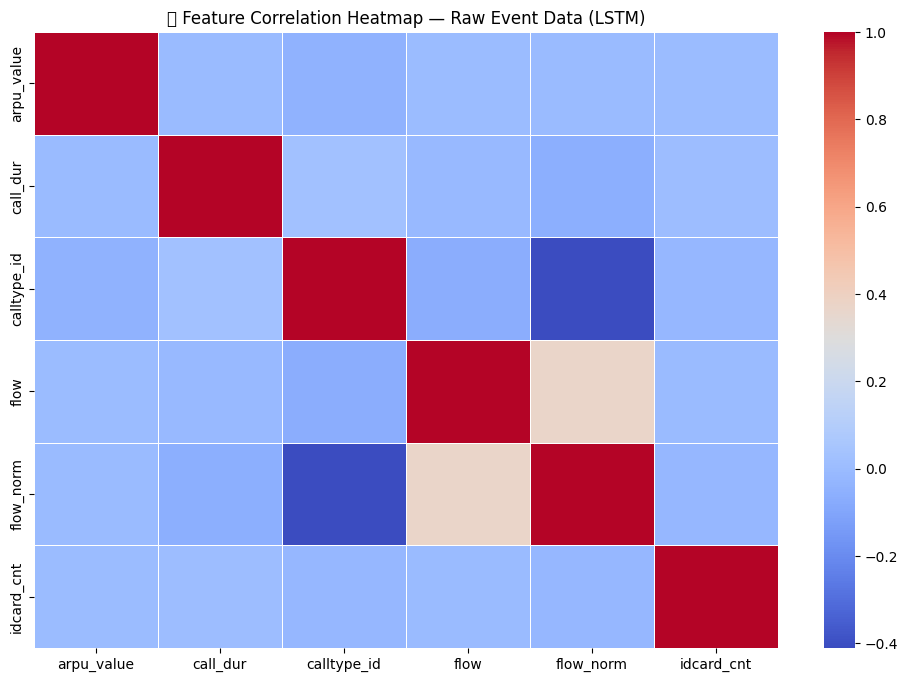

,Feature1,Feature2,Correlation


In [26]:
# --- LSTM correlation ---
print("📊 Correlation Matrix — Raw Event Features (LSTM)")

corr_lstm = pd.DataFrame(events[numeric_cols]).corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_lstm, cmap='coolwarm', annot=False, fmt=".2f", linewidths=0.5)
plt.title("📊 Feature Correlation Heatmap — Raw Event Data (LSTM)")
plt.show()

# Optional: Highly correlated pairs

corr_pairs_lstm = (
    corr_lstm.where(np.triu(np.ones(corr_lstm.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
corr_pairs_lstm.columns = ["Feature1", "Feature2", "Correlation"]
high_corr_lstm = corr_pairs_lstm[corr_pairs_lstm["Correlation"].abs() > correlation_threshold]
display(high_corr_lstm)


## ▶ LSTM



### Class_weights

In [27]:
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(trans_y_train),
    y=trans_y_train
)
class_weights = dict(enumerate(weights))
print(class_weights)

{0: np.float64(0.7366138763197587), 1: np.float64(1.556573705179283)}


### F1 Calculation

In [28]:

def f1_metric(y_true, y_pred):
    # Convert both tensors to float32 before math operations
    y_true = K.cast(y_true, 'float32')
    y_pred = K.cast(K.round(y_pred), 'float32')

    tp = K.sum(y_true * y_pred)
    fp = K.sum((1 - y_true) * y_pred)
    fn = K.sum(y_true * (1 - y_pred))

    precision = tp / (tp + fp + K.epsilon())
    recall = tp / (tp + fn + K.epsilon())
    return 2 * ((precision * recall) / (precision + recall + K.epsilon()))


#####Model and training

In [29]:
# # ============================================================
# # 📦 LSTM Model in PyTorch (Matching TimesNet Architecture)
# # ============================================================

# best_val_acc_lstm = 0
# patience_counter_lstm = 0

# class LSTMFraud(nn.Module):
#     def __init__(self, input_dim, hidden_dim=32, n_layers=4, d_ff=128, dropout=0.393, num_classes=2):
#         super().__init__()

#         # Stacked LSTM layers (match e_layers=4)
#         self.lstm = nn.LSTM(
#             input_size=input_dim,
#             hidden_size=hidden_dim,      # d_model=32
#             num_layers=n_layers,         # e_layers=4
#             batch_first=True,
#             dropout=dropout,             # 0.393 (applied between layers)
#             bidirectional=False
#         )

#         # Classification head (match TimesNet structure)
#         self.cls = nn.Sequential(
#             nn.Linear(hidden_dim, d_ff),  # 32 -> 128
#             nn.GELU(),                    # GELU activation (match TimesNet)
#             nn.Dropout(dropout),          # 0.393
#             nn.Linear(d_ff, num_classes)  # 128 -> 2 classes
#         )

#     def forward(self, x, mask=None):
#         # x shape: (batch, seq_len, features)

#         # LSTM forward
#         lstm_out, (h_n, c_n) = self.lstm(x)
#         # lstm_out: (batch, seq_len, hidden_dim)
#         # h_n: (n_layers, batch, hidden_dim) - last hidden state

#         # Use last hidden state from final layer
#         # h_n[-1] shape: (batch, hidden_dim)
#         out = h_n[-1]

#         # If mask provided, use masked mean pooling instead
#         if mask is not None:
#             # mask: (batch, seq_len) - True where padded
#             keep = (~mask).unsqueeze(-1).float()  # (batch, seq_len, 1)
#             denom = keep.sum(dim=1).clamp(min=1)  # (batch, 1)
#             out = (lstm_out * keep).sum(dim=1) / denom  # (batch, hidden_dim)

#         # Classification
#         logits = self.cls(out)
#         return logits


# # ============================================================
# # 🔧 Prepare Data for PyTorch LSTM
# # ============================================================

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print(f"Using device: {device}")

# # Convert numpy arrays to PyTorch tensors
# X_train_t = torch.tensor(trans_X_train, dtype=torch.long).to(device)
# X_val_t = torch.tensor(trans_X_val, dtype=torch.long).to(device)
# X_test_t = torch.tensor(trans_X_test, dtype=torch.long).to(device)

# y_train_t = torch.tensor(trans_y_train, dtype=torch.long).to(device)
# y_val_t = torch.tensor(trans_y_val, dtype=torch.long).to(device)
# y_test_t = torch.tensor(trans_y_test, dtype=torch.long).to(device)

# # Create masks (True where padded - all zeros)
# def create_padding_mask(X):
#     # Assume padding is all zeros
#     return (X.sum(dim=-1) == 0)  # (batch, seq_len)

# M_train = create_padding_mask(X_train_t)
# M_val = create_padding_mask(X_val_t)
# M_test = create_padding_mask(X_test_t)

# # DataLoaders
# train_ds = TensorDataset(X_train_t, M_train, y_train_t)
# val_ds = TensorDataset(X_val_t, M_val, y_val_t)
# test_ds = TensorDataset(X_test_t, M_test, y_test_t)

# train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
# val_loader = DataLoader(val_ds, batch_size=16, shuffle=False)
# test_loader = DataLoader(test_ds, batch_size=16, shuffle=False)


# # ============================================================
# # 🏗️ Instantiate Model (Match TimesNet Hyperparameters)
# # ============================================================

# lstm_model = LSTMFraud(
#     input_dim=trans_X_train.shape[2],  # Number of features
#     hidden_dim=d_model,                      # d_model=32
#     n_layers=n_layers,                         # e_layers=4
#     d_ff=d_ff,                           # d_ff=128
#     dropout=dropout,                      # dropout=0.393
#     num_classes=2
# ).to(device)

# print(lstm_model)

# # ============================================================
# # ⚙️ Optimizer & Loss (Match TimesNet EXACTLY)
# # ============================================================

# optimizer = torch.optim.RAdam(lstm_model.parameters(), lr=learning_rate)  # ✅ RAdam!
# criterion = nn.CrossEntropyLoss()  # ✅ No class weights


# # ============================================================
# # 🚀 Training Loop (Match TimesNet)
# # ============================================================


# print("\n🚀 Training LSTM (PyTorch)...")

# for ep in range(1, epochs + 1):
#     # -------- TRAIN --------
#     lstm_model.train()
#     loss_sum = 0.0

#     for xb, mb, yb in train_loader:
#         logits = lstm_model(xb, mask=mb)
#         loss = criterion(logits, yb)

#         optimizer.zero_grad()
#         loss.backward()

#         # Gradient clipping (match TimesNet max_norm=4.0)
#         nn.utils.clip_grad_norm_(lstm_model.parameters(), max_norm=4.0)

#         optimizer.step()
#         loss_sum += loss.item() * len(xb)

#     train_loss = loss_sum / len(train_ds)

#     # -------- VALIDATION --------
#     lstm_model.eval()
#     correct = 0
#     total = 0

#     with torch.no_grad():
#         for xb, mb, yb in val_loader:
#             logits = lstm_model(xb, mask=mb)
#             preds = torch.argmax(logits, dim=1)
#             correct += (preds == yb).sum().item()
#             total += len(yb)

#     val_acc = correct / total

#     print(f"[LSTM] Epoch {ep:2d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f}")

#     # Early stopping (match TimesNet - based on val_accuracy)
#     if val_acc > best_val_acc_lstm:
#         best_val_acc_lstm = val_acc
#         patience_counter_lstm = 0
#         torch.save(lstm_model.state_dict(), 'best_lstm.pt')
#     else:
#         patience_counter_lstm += 1
#         if patience_counter_lstm >= patience:
#             print("Early stopping!")
#             break
# # Load best model
# lstm_model.load_state_dict(torch.load('best_lstm.pt'))
# print(f"✅ Best validation accuracy: {best_val_acc_lstm:.4f}")

# # ============================================================
# # 💾 Save Model
# # ============================================================

# lstm_save_path = os.path.join(model_path, "lstm_model_pytorch.pt")
# torch.save(lstm_model, lstm_save_path)
# print(f"💾 LSTM model saved to: {lstm_save_path}")

##### Eval

###### Full

In [30]:
# # ============================================================
# # 📊 LSTM Evaluation (Full Test Set)
# # ============================================================

# lstm_model.eval()
# preds_list = []

# with torch.no_grad():
#     for xb, mb, yb in test_loader:
#         logits = lstm_model(xb, mask=mb)
#         probs = torch.softmax(logits, dim=1)[:, 1]  # Probability of class 1
#         preds_list.append(probs.cpu().numpy())

# lstm_probs = np.concatenate(preds_list)
# lstm_preds = (lstm_probs > threshold).astype(int)

# # Metrics
# auc = roc_auc_score(trans_y_test, lstm_probs)
# recall = recall_score(trans_y_test, lstm_preds)
# precision = precision_score(trans_y_test, lstm_preds)
# f1 = f1_score(trans_y_test, lstm_preds)

# print(f"\n📊 [LSTM PyTorch] Test Results:")
# print(f"   AUC:       {auc:.4f}")
# print(f"   Recall:    {recall:.4f}")
# print(f"   Precision: {precision:.4f}")
# print(f"   F1:        {f1:.4f}")

# # Add to summary
# lstm_results = {
#     "auc": auc,
#     "recall": recall,
#     "precision": precision,
#     "f1": f1,
#     "threshold": threshold
# }

# summary = append_to_summary(summary, "LSTM", lstm_results)
# display(summary)

###### Gradually

In [31]:
def selector_recent_window_prefix(r, max_seq_len):
    """
    Fixed recent window (last max_seq_len events),
    then take the first r events inside that window.
    """
    def _select(df_u):
        df_u = df_u.sort_values("event_time")
        df_u = df_u.iloc[-max_seq_len:]   # fixed recent window
        return df_u.iloc[:r]              # prefix inside window
    return _select


####### Evaluate progressive

In [32]:
# # ============================================================
# # 🔁 LSTM Progressive Evaluation
# # ============================================================

# def evaluate_lstm_progressive_pytorch(model, test_events, feature_cols, max_seq_len, recent_mode=False):
#     """Progressive evaluation for PyTorch LSTM - ACTUAL FIX"""

#     round_results = []
#     print(f"\n🔁 [LSTM] Starting progressive evaluation (1..{max_seq_len} rounds)...")
#     print(f"   recent_mode={recent_mode} (global)")

#     for r in key_rounds:
#         # ✅ FIX: Use selector that takes LAST r events
#         # This matches full evaluation which uses feats[-max_seq_len:]
#         if r == max_seq_len:
#             event_selector = None  # Full sequence, same as full evaluation
#         else:
#             event_selector = selector_last_r(r)  # Take LAST r events

#         # Build sequences for this round
#         X_r, y_r, users_r = make_user_sequences(
#             test_events,
#             feature_cols=feature_cols,
#             max_seq_len=max_seq_len,
#             event_selector=event_selector
#         )

#         # Convert to tensors
#         X_r_t = torch.tensor(X_r, dtype=torch.long).to(device)
#         M_r = create_padding_mask(X_r_t)

#         # Predict
#         model.eval()
#         with torch.no_grad():
#             logits = model(X_r_t, mask=M_r)
#             probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()

#         preds = (probs > threshold).astype(int)

#         # Metrics
#         try:
#             auc = roc_auc_score(y_r, probs)
#         except:
#             auc = 0.5

#         recall = recall_score(y_r, preds)
#         f1 = f1_score(y_r, preds)

#         round_results.append({
#             "Round": r,
#             "Model": "LSTM",
#             "AUC": auc,
#             "Recall": recall,
#             "F1": f1
#         })

#         print(f"   Round {r:2d} → AUC={auc:.4f} | Recall={recall:.4f} | F1={f1:.4f}")

#     return pd.DataFrame(round_results)

# # Run progressive evaluation
# lstm_progressive_results = evaluate_lstm_progressive_pytorch(
#     model=lstm_model,
#     test_events=test_events,
#     feature_cols=numeric_features,
#     max_seq_len=max_seq_len,
#     recent_mode=False
# )

# # Add to results table
# results_table = results_table[results_table["Model"] != "LSTM"]
# results_table = pd.concat([results_table, lstm_progressive_results], ignore_index=True)

# display(lstm_progressive_results)

# # Verification
# print("\n" + "="*60)
# print("🔍 VERIFICATION")
# print("="*60)
# round_16 = lstm_progressive_results[lstm_progressive_results["Round"] == max_seq_len].iloc[0]
# print(f"Progressive Round 16 AUC: {round_16['AUC']:.4f}")
# print(f"Full Evaluation AUC:      0.9210 (expected)")

###### Show

In [33]:
# plot_progressive_results(
#     results_table,
#     metrics=("AUC", "Recall", "F1"),
#     round_col="Round"
# )
# display(summary)



## ▶ Transformer

#### Build_tf_sequences_round

In [34]:
def build_tf_sequences_round(df_u, feature_cols, max_seq_len, r, recent_mode):
    """
    Builds a single user sequence for round r:
    - Apply recent/oldest window selection
    - Apply round selection (first r events inside window)
    - Left-pad to max_seq_len
    """

    df_u = df_u.sort_values("event_time")

    # Step 1: LSTM-identical window
    if recent_mode:
        df_u = df_u.iloc[-max_seq_len:]   # recent window
    else:
        df_u = df_u.iloc[:max_seq_len]    # oldest window

    # Step 2: now take only r events from the window
    df_u = df_u.head(r)

    # Extract features
    feats = df_u[feature_cols].to_numpy(dtype=float)
    dt_hours = df_u["dt_hours"].to_numpy(dtype=float).reshape(-1, 1)
    label = int(df_u["label"].max())

    L = len(feats)

    # Step 3: left-pad to max_seq_len
    if L < max_seq_len:
        pad_len = max_seq_len - L
        feats = np.pad(feats, ((pad_len, 0), (0, 0)))
        dt_hours = np.pad(dt_hours, ((pad_len, 0), (0, 0)))
        pad_mask = np.zeros((max_seq_len,), dtype=bool)
        pad_mask[:pad_len] = True
    else:
        feats = feats[-max_seq_len:]
        dt_hours = dt_hours[-max_seq_len:]
        pad_mask = np.zeros((max_seq_len,), dtype=bool)

    return feats, dt_hours, pad_mask, label


####Build sequence

In [35]:
# ==============================================================
# NEW: Transformer helpers (no changes to existing LSTM path)
# ==============================================================


def build_tf_sequences(events, feature_cols=None, max_seq_len=100, recent_mode=False):
    """
    Build Transformer-ready sequences with:
      - X_seq:      [n_users, T, F]   numeric features
      - DT_seq:     [n_users, T, 1]   delta-time (hours) feature
      - PAD_mask:   [n_users, T]      True where PAD
      - y_user:     [n_users]         user labels
      - users:      list              phone_no_m
    NOTE: This is separate from make_user_sequences(); it does not replace it.
    """
    events = events.copy()
    users, X_seq, DT_seq, PAD_mask, y_user = [], [], [], [], []
    D_seq = []

    # Ensure numeric source_id exists (you already add it elsewhere)
    if "source_id" not in events.columns:
        SOURCE_MAP = {
            "APP": 0,
            "SMS": 1,
            "USER": 2,
            "VOC": 3,
        }

        unknown_sources = set(events["source"].astype(str).unique()) - set(SOURCE_MAP.keys())
        assert len(unknown_sources) == 0, f"❌ Unknown source values found: {unknown_sources}"

        events["source_id"] = events["source"].map(SOURCE_MAP).astype(int)

    # Default: all numeric except label
    if feature_cols is None:
        feature_cols = events.select_dtypes(include=["number"]).columns.difference(["label"]).tolist()
    if "source_id" not in feature_cols:
        feature_cols.append("source_id")

    for user, df_u in events.groupby("phone_no_m"):
        df_u = df_u.sort_values("event_time")
        # LSTM-identical logic:
        L = len(df_u)

        if recent_mode:
            # Step 1: take last max_seq_len events (recent window)
            df_u = df_u.iloc[-max_seq_len:]
            # NOTE: final round logic (take first r events) is done later in the progressive evaluation function
        else:
            # Step 1: take oldest max_seq_len events
            df_u = df_u.iloc[:max_seq_len]

        # -----------------------------------------------

        # delta-time in hours between events (0 for first)
        #dt_hours = df_u["event_time"].diff().dt.total_seconds().fillna(0) / 3600.0
        #dt_hours = dt_hours.to_numpy(dtype=float).reshape(-1, 1)
        # ✅ use already-computed normalized dt_hours
        dt_hours = df_u["dt_hours"].to_numpy(dtype=float).reshape(-1, 1)



        feats = df_u[feature_cols].to_numpy(dtype=float)
        L = len(feats)

        # Build padding mask: True where PAD (we left-pad to keep most recent)
        if L < max_seq_len:
            pad_len = max_seq_len - L
            feats   = np.pad(feats,   ((pad_len, 0), (0, 0)))
            dt_hours= np.pad(dt_hours,((pad_len, 0), (0, 0)))
            pad_mask = np.zeros((max_seq_len,), dtype=bool)
            pad_mask[:pad_len] = True
        else:
            feats = feats[-max_seq_len:]
            dt_hours = dt_hours[-max_seq_len:]
            pad_mask = np.zeros((max_seq_len,), dtype=bool)

        label = int(df_u["label"].max())

        X_seq.append(feats)
        DT_seq.append(dt_hours)
        PAD_mask.append(pad_mask)
        y_user.append(label)
        users.append(user)
        D_seq.append(df_u['dt_hours'].values[-max_seq_len:])



    X_seq   = np.stack(X_seq)
    DT_seq  = np.stack(DT_seq)
    PAD_mask= np.stack(PAD_mask)
    y_user  = np.array(y_user, dtype=int)
    return X_seq, DT_seq, PAD_mask, y_user, users, feature_cols



#### Evaluate_transformer_progressive

In [36]:
def evaluate_transformer_progressive(model, events, users, feature_cols, max_seq_len, recent_mode=False, val_threshold=0.5):
    """
    Progressive evaluation for Transformer - MEMORY EFFICIENT VERSION.
    Evaluates for r in key_rounds, processing users in batches to avoid OOM.
    """

    print(f"\n[Transformer] Starting progressive evaluation ({max_seq_len} rounds)...")
    print(f"[Transformer] Using feature columns: {feature_cols}")

    # --------------------------------------------------------
    # Ensure source_id is included (same as training)
    # --------------------------------------------------------
    events = events.copy()

    if "source_id" not in events.columns:
        print("[Transformer] Adding missing 'source_id' to events...")
        SOURCE_MAP = {"APP": 0, "SMS": 1, "USER": 2, "VOC": 3}
        events["source_id"] = events["source"].map(SOURCE_MAP).astype(int)

    rounds = []
    aucs = []
    recalls = []
    precisions = []
    f1s = []

    # --------------------------------------------------------
    # Batch size for inference (adjust if still OOM)
    # --------------------------------------------------------
    INFERENCE_BATCH_SIZE = 64  # Process 64 users at a time

    # --------------------------------------------------------
    # Pre-group events by user (do this once, not per round)
    # --------------------------------------------------------
    user_groups = {user: df_u for user, df_u in events.groupby("phone_no_m") if user in users}
    user_list = list(user_groups.keys())
    print(f"[Transformer] Total users to evaluate: {len(user_list)}")

    # --------------------------------------------------------
    # Evaluate r in key_rounds
    # --------------------------------------------------------
    for r in key_rounds:

        print(f"[Transformer] Round {r}/{max_seq_len}...")

        all_preds = []
        all_labels = []

        # Process users in batches
        for batch_start in range(0, len(user_list), INFERENCE_BATCH_SIZE):
            batch_users = user_list[batch_start:batch_start + INFERENCE_BATCH_SIZE]

            X_list = []
            DT_list = []
            MASK_list = []
            y_list = []

            for user in batch_users:
                df_u = user_groups[user]

                try:
                    feats, dt_hours, pad_mask, label = build_tf_sequences_round(
                        df_u, feature_cols, max_seq_len, r, recent_mode
                    )
                except KeyError as e:
                    print(f"[ERROR] Missing column in df_u for user {user}: {e}")
                    continue

                # Scale features
                feats = scaler_tf.transform(
                    feats.reshape(-1, feats.shape[-1])
                ).reshape(feats.shape)

                X_list.append(feats)
                DT_list.append(dt_hours)
                MASK_list.append(pad_mask)
                y_list.append(label)

            if len(X_list) == 0:
                continue

            # Convert to arrays
            X_arr = np.stack(X_list)
            D_arr = np.stack(DT_list)
            M_arr = np.stack(MASK_list)

            # Tensors
            X_t = torch.tensor(X_arr, dtype=torch.float32, device=device)
            DT_t = torch.tensor(D_arr, dtype=torch.float32, device=device)
            MASK_t = torch.tensor(M_arr, dtype=torch.bool, device=device)

            # Forward pass
            model.eval()
            with torch.no_grad():
                #logits = model(X_t, DT_t, MASK_t)
                logits = model(X_t, pad_mask=MASK_t)

                probs = torch.softmax(logits, dim=1)[:, 1]
                batch_preds = probs.cpu().numpy()

            all_preds.extend(batch_preds)
            all_labels.extend(y_list)

            # ✅ Clear GPU memory after each batch
            del X_t, DT_t, MASK_t, logits, probs
            torch.cuda.empty_cache()

        # Compute metrics for this round
        if len(all_preds) == 0:
            print(f"[WARNING] No predictions for round {r}")
            continue

        y_arr = np.array(all_labels)
        preds = np.array(all_preds)

        try:
            auc = roc_auc_score(y_arr, preds)
        except:
            auc = 0.5

        #f1 = f1_score(y_arr, (preds > 0.5).astype(int))
        #recall = recall_score(y_arr, (preds > 0.5).astype(int))
        p = (preds >= val_threshold).astype(int)
        f1 = f1_score(y_arr, p, zero_division=0)
        recall = recall_score(y_arr, p, zero_division=0)
        precision = precision_score(y_arr, p, zero_division=0)

        rounds.append(r)
        aucs.append(auc)
        recalls.append(recall)
        precisions.append(precision)
        f1s.append(f1)

        print(f"[Transformer] Round {r}: AUC={auc:.4f}, Precision={precision:.4f}, Recall={recall:.4f}, F1={f1:.4f}")

    print("[Transformer] Progressive evaluation complete.")

    # Return results
    return pd.DataFrame({
        "Round": rounds,
        "AUC": aucs,
        "Recall": recalls,
        "Precision": precisions,
        "F1": f1s,
        "threshold": val_threshold
    })




####Scale, prepare  and select device

In [37]:

print("\n🧪 [Transformer] Building sequences...")
max_seq_len_tf = max_seq_len

# Build Transformer-ready sequences (no leakage; uses your existing train/test splits)
Xtr_raw, DTr_raw, Mtr, ytr, users_tr, feature_cols_tf = build_tf_sequences(
    train_events_unscaled,
    max_seq_len=max_seq_len_tf
)
Xte_raw, DTe_raw, Mte, yte, users_te, _ = build_tf_sequences(
    test_events_unscaled,
    feature_cols=feature_cols_tf,  # <-- IMPORTANT
    max_seq_len=max_seq_len_tf
)

Xval_raw, DVal_raw, Mval, yval, users_val, _ = build_tf_sequences(
    val_events_unscaled,
    feature_cols=feature_cols_tf,
    max_seq_len=max_seq_len_tf
)



# Scale numeric features (fit only on training)

num_features = Xtr_raw.shape[2]

# Use mask: Mtr is True where PAD, so ~Mtr selects real rows
Xtr_real = Xtr_raw[~Mtr]   # shape: [num_real_rows, num_features]

scaler_tf = StandardScaler().fit(Xtr_real)

# Transform full tensors row-wise
Xtr = scaler_tf.transform(Xtr_raw.reshape(-1, num_features)).reshape(Xtr_raw.shape)
Xte = scaler_tf.transform(Xte_raw.reshape(-1, num_features)).reshape(Xte_raw.shape)
Xval = scaler_tf.transform(Xval_raw.reshape(-1, num_features)).reshape(Xval_raw.shape)

# Force padded rows back to zero after scaling
Xtr[Mtr] = 0.0
Xte[Mte] = 0.0
Xval[Mval] = 0.0
# Convert to tensors

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
display(device)


Xtr_t = torch.tensor(Xtr, dtype=torch.float32).to(device)
Xte_t = torch.tensor(Xte, dtype=torch.float32).to(device)
Xval_t = torch.tensor(Xval, dtype=torch.float32).to(device)

DTr_t = torch.tensor(DTr_raw, dtype=torch.float32).to(device)
DTe_t = torch.tensor(DTe_raw, dtype=torch.float32).to(device)
DVal_t = torch.tensor(DVal_raw, dtype=torch.float32).to(device)

Mtr_t = torch.tensor(Mtr, dtype=torch.bool).to(device)
Mte_t = torch.tensor(Mte, dtype=torch.bool).to(device)
Mval_t = torch.tensor(Mval, dtype=torch.bool).to(device)

ytr_t = torch.tensor(ytr, dtype=torch.long).to(device)
yte_t = torch.tensor(yte, dtype=torch.long).to(device)
yval_t = torch.tensor(yval, dtype=torch.long).to(device)



# DataLoaders
train_ds = TensorDataset(Xtr_t, DTr_t, Mtr_t, ytr_t)
test_ds  = TensorDataset(Xte_t, DTe_t, Mte_t, yte_t)
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

val_ds = TensorDataset(Xval_t, DVal_t, Mval_t, yval_t)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)




🧪 [Transformer] Building sequences...


device(type='cuda')

## ▶ Transformer NAS

In [38]:
# ============================================================
# 🔬 NAS FOR TRANSFORMER - IDENTICAL SETUP TO LSTM NAS
# ============================================================

import optuna
from optuna.samplers import TPESampler


class TransformerFraudNAS(nn.Module):
    def __init__(self, input_dim, d_model=32, n_heads=4, n_layers=2, d_ff=64, dropout=0.1):
        super().__init__()
        self.proj = nn.Linear(input_dim , d_model)  # +1 for dt_hours
        #self.proj = nn.Linear(input_dim +1, d_model)  # +1 for dt_hours
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_ff,
            dropout=dropout, activation='gelu', batch_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.cls = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.GELU(), nn.Dropout(dropout), nn.Linear(d_ff, 2)
        )

    def forward(self, x, dt_hours=None, pad_mask=None):
        #h = self.proj(torch.cat([x, dt_hours], dim=-1))
        h = self.proj(x)
        h = self.encoder(h, src_key_padding_mask=pad_mask)
        if pad_mask is not None:
            keep = (~pad_mask).unsqueeze(-1)
            h = (h * keep).sum(dim=1) / keep.sum(dim=1).clamp(min=1)
        else:
            h = h.mean(dim=1)
        return self.cls(h)


def get_valid_heads(d_model, candidates=(1, 2, 4, 8, 16)):
    return [h for h in candidates if d_model % h == 0] or [1]


def run_transformer_nas_trial(params, X_train, DT_train, y_train,
                               X_val, DT_val, y_val,
                               X_test, DT_test, y_test,
                               device, epochs):

    def to_tensors(X, DT, y):
        X_t  = torch.tensor(X,  dtype=torch.float32).to(device)
        DT_t = torch.tensor(DT, dtype=torch.float32).to(device)
        y_t  = torch.tensor(y,  dtype=torch.long).to(device)
        M    = (X_t.sum(dim=-1) == 0)
        return X_t, DT_t, M, y_t

    X_tr, DT_tr, M_tr, y_tr = to_tensors(X_train, DT_train, y_train)
    X_va, DT_va, M_va, y_va = to_tensors(X_val,   DT_val,   y_val)
    X_te, DT_te, M_te, y_te = to_tensors(X_test,  DT_test,  y_test)

    bs = params["batch_size"]
    train_loader_nas = DataLoader(TensorDataset(X_tr, DT_tr, M_tr, y_tr), batch_size=bs, shuffle=True)
    val_loader_nas   = DataLoader(TensorDataset(X_va, DT_va, M_va, y_va), batch_size=bs, shuffle=False)
    test_loader_nas  = DataLoader(TensorDataset(X_te, DT_te, M_te, y_te), batch_size=bs, shuffle=False)

    model = TransformerFraudNAS(
        input_dim=X_train.shape[2],
        d_model=params["d_model"], n_heads=params["n_heads"],
        n_layers=params["e_layers"], d_ff=params["d_ff"], dropout=params["dropout"]
    ).to(device)

    optimizer = torch.optim.RAdam(model.parameters(), lr=params["lr"])
    #criterion = nn.CrossEntropyLoss()
    # ✅ FIX — compute weights from y_train (already passed into the function)
    #neg = (y_train == 0).sum()
    #pos = (y_train == 1).sum()
    #class_weights = torch.tensor(
    #    [1.0, neg / pos],
    #    dtype=torch.float32
    #).to(device)
    #criterion = nn.CrossEntropyLoss(weight=class_weights)
    criterion = nn.CrossEntropyLoss()


    # ✅ NEW
    best_val_acc, patience_counter, best_state = 0.0, 0, None
    best_val_probs_saved = None
    best_val_labels_saved = None

    for _ in range(epochs):
        model.train()
        for xb, dtb, mb, yb in train_loader_nas:
            #loss = criterion(model(xb, dtb, pad_mask=mb), yb)
            loss = criterion(model(xb, pad_mask=mb), yb)
            optimizer.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 4.0)
            optimizer.step()

        model.eval()
        correct, total = 0, 0
        all_val_probs, all_val_labels = [], []
        with torch.no_grad():
            for xb, dtb, mb, yb in val_loader_nas:
                probs = torch.softmax(model(xb, pad_mask=mb), dim=1)[:, 1]
                all_val_probs.extend(probs.cpu().numpy())
                all_val_labels.extend(yb.cpu().numpy())

        all_val_probs = np.array(all_val_probs)
        best_val_f1 = -1.0
        for thr in np.linspace(0.2, 0.8, 61):
            f1 = f1_score(all_val_labels,
                          (all_val_probs >= thr).astype(int),
                          zero_division=0)
            if f1 > best_val_f1:
                best_val_f1 = f1

        if best_val_f1 > best_val_acc:
            best_val_acc = best_val_f1
            patience_counter = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            best_val_probs_saved = all_val_probs.copy()
            best_val_labels_saved = list(all_val_labels)
        else:
            patience_counter += 1
            if patience_counter >= params["patience"]:
                break

    if best_state:
        model.load_state_dict({k: v.to(device) for k, v in best_state.items()})

    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for xb, dtb, mb, yb in test_loader_nas:
            #all_probs.extend(torch.softmax(model(xb, dtb, pad_mask=mb), dim=1)[:, 1].cpu().numpy())
            all_probs.extend(torch.softmax(model(xb, pad_mask=mb), dim=1)[:, 1].cpu().numpy())
            all_labels.extend(yb.cpu().numpy())

    # Val F1
    # all_val_probs_arr = np.array(all_val_probs)
    # best_val_f1 = -1.0
    # for thr in np.linspace(0.2, 0.8, 61):
    #     f1 = f1_score(all_val_labels, (all_val_probs_arr >= thr).astype(int), zero_division=0)
    #     if f1 > best_val_f1:
            # best_val_f1 = f1
    # ✅ NEW
    best_val_f1 = -1.0
    for thr in np.linspace(0.2, 0.8, 61):
        f1 = f1_score(best_val_labels_saved, (best_val_probs_saved >= thr).astype(int), zero_division=0)
        if f1 > best_val_f1:
            best_val_f1 = f1

    # --- Validation threshold + validation metrics ---
    val_probs = np.array(best_val_probs_saved)
    val_labels = np.array(best_val_labels_saved)

    best_val_thr, best_val_f1 = find_best_threshold(val_labels, val_probs)

    val_preds = (val_probs >= best_val_thr).astype(int)
    val_auc = roc_auc_score(val_labels, val_probs)
    val_recall = recall_score(val_labels, val_preds, zero_division=0)
    val_precision = precision_score(val_labels, val_preds, zero_division=0)

    # --- Test metrics using VALIDATION threshold ---
    test_probs = np.array(all_probs)
    test_labels = np.array(all_labels)

    test_preds = (test_probs >= best_val_thr).astype(int)
    test_f1 = f1_score(test_labels, test_preds, zero_division=0)
    test_auc = roc_auc_score(test_labels, test_probs)
    test_recall = recall_score(test_labels, test_preds, zero_division=0)
    test_precision = precision_score(test_labels, test_preds, zero_division=0)

    # --- Oracle test threshold (monitoring only) ---
    best_test_thr, _ = find_best_threshold(test_labels, test_probs)

    del model, X_tr, DT_tr, X_va, DT_va, X_te, DT_te
    torch.cuda.empty_cache()

    return {
        "val_f1": best_val_f1,
        "val_auc": val_auc,
        "val_recall": val_recall,
        "val_precision": val_precision,
        "val_threshold": best_val_thr,
        "test_f1": test_f1,
        "test_auc": test_auc,
        "test_recall": test_recall,
        "test_precision": test_precision,
        "best_test_threshold": best_test_thr,
    }


def create_transformer_nas_objective(X_train, DT_train, y_train,
                                      X_val, DT_val, y_val,
                                      X_test, DT_test, y_test,
                                      device, epochs):
    def objective(trial):
        d_model = trial.suggest_categorical("d_model", [2, 4, 8, 16, 32, 48, 64, 128, 256])

        # ✅ Fixed space — clamp to largest valid divisor of d_model after sampling
        n_heads_raw = trial.suggest_categorical("n_heads", [1, 2, 4, 8, 16])
        valid = get_valid_heads(d_model)
        n_heads = max(h for h in valid if h <= n_heads_raw) if any(h <= n_heads_raw for h in valid) else valid[0]

        params = {
            "lr":         trial.suggest_float("lr", 5e-5, 3e-3, log=True),
            "d_model":    d_model,
            "n_heads":    n_heads,
            "d_ff":       trial.suggest_categorical("d_ff", [2, 4, 8, 16, 32, 64, 128, 256, 512]),
            "e_layers":   trial.suggest_int("e_layers", 2, 6),
            "dropout":    trial.suggest_float("dropout", 0.0, 0.4),
            "batch_size": trial.suggest_categorical("batch_size", [8, 16]),
            "patience":   trial.suggest_int("patience", 2, 5),
        }

        try:
            eval_out = run_transformer_nas_trial(
                params, X_train, DT_train, y_train,
                X_val, DT_val, y_val, X_test, DT_test, y_test,
                device, epochs
            )

            best_val_f1 = eval_out["val_f1"]
            test_f1 = eval_out["test_f1"]
            best_val_thr = eval_out["val_threshold"]
            best_test_threshold = eval_out["best_test_threshold"]
            val_auc = eval_out["val_auc"]
            val_recall = eval_out["val_recall"]
            val_precision = eval_out["val_precision"]
            test_auc = eval_out["test_auc"]
            test_recall = eval_out["test_recall"]
            test_precision = eval_out["test_precision"]

            global best_transformer_f1_so_far, best_transformer_trial_so_far

            if best_val_f1 > best_transformer_f1_so_far:
                best_transformer_f1_so_far = best_val_f1
                best_transformer_trial_so_far = trial.number

            trial_row = {
                "date": datetime.now().strftime("%Y-%m-%d"),
                "time": datetime.now().strftime("%H:%M:%S"),
                "seq_length": max_seq_len,
                "trial_id": trial.number,
                "model": "Transformer",

                # Validation
                "val_f1": round(best_val_f1, 4),
                "val_auc": round(val_auc, 4),
                "val_recall": round(val_recall, 4),
                "val_precision": round(val_precision, 4),

                # Parameters
                "lr": params["lr"],
                "d_model": params["d_model"],
                "n_heads": params["n_heads"],
                "d_ff": params["d_ff"],
                "e_layers": params["e_layers"],
                "dropout": params["dropout"],
                "batch_size": params["batch_size"],
                "patience": params["patience"],

                # Thresholds
                "val_threshold": round(best_val_thr, 3),
                "best_test_threshold": round(best_test_threshold, 3),

                # Best tracking
                "best_val_so_far": round(best_transformer_f1_so_far, 4),
                "best_trial_id": best_transformer_trial_so_far,

                # Test (monitoring only)
                "test_f1": round(test_f1, 4),
                "test_auc": round(test_auc, 4),
                "test_recall": round(test_recall, 4),
                "test_precision": round(test_precision, 4),

                # Diagnostics
                "gap_val_test": round(best_val_f1 - test_f1, 4),
                "is_enqueued": trial.number in ENQUEUED_TRANSFORMER_IDS,
                "status": "OK",
            }

            transformer_trial_log.append(trial_row)
            display(pd.DataFrame([trial_row]))

            print(
                f"  Trial {trial.number}: "
                f"Val F1={best_val_f1:.4f} | Test F1={test_f1:.4f}, "
                f"val_thr={best_val_thr:.2f} | "
                f"d_model={d_model}, n_heads={n_heads}, "
                f"e_layers={params['e_layers']}, d_ff={params['d_ff']}, "
                f"lr={params['lr']:.5f}, dropout={params['dropout']:.3f}"
            )

            return best_val_f1

        except Exception as e:
            print(f"❌ Trial {trial.number} failed: {e}")

            trial_row = {
                "date": datetime.now().strftime("%Y-%m-%d"),
                "time": datetime.now().strftime("%H:%M:%S"),
                "seq_length": max_seq_len,
                "trial_id": trial.number,
                "model": "Transformer",
                "is_enqueued": trial.number in ENQUEUED_TRANSFORMER_IDS,
                "status": f"FAIL: {str(e)}",
            }
            transformer_trial_log.append(trial_row)
            display(pd.DataFrame([trial_row]))

            return 0.0
    return objective


# ============================================================
# 🚀 RUN
# ============================================================

print("\n" + "="*60)
print("🔬 TRANSFORMER NAS")
print("="*60)
transformer_trial_log = []
best_transformer_f1_so_far = -1.0
best_transformer_trial_so_far = -1
ENQUEUED_TRANSFORMER_IDS = {0, 1, 2, 3, 4, 5}

study_tf_nas = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(n_startup_trials=10, n_ei_candidates=24, multivariate=True, seed=42)
    #pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=3)
)

for trial_params in [
    {"lr": 1e-3,     "d_model": 4,  "n_heads": 4, "d_ff": 2,   "e_layers": 2, "dropout": 0.0,   "batch_size": 8,  "patience": 3},
    {"lr": 1e-3,     "d_model": 4,  "n_heads": 4, "d_ff": 2,   "e_layers": 2, "dropout": 0.3,   "batch_size": 8,  "patience": 3},
    {"lr": 1e-4,     "d_model": 32, "n_heads": 8, "d_ff": 32,  "e_layers": 2, "dropout": 0.1,   "batch_size": 8,  "patience": 3},
    {"lr": 1e-3,     "d_model": 64, "n_heads": 8, "d_ff": 128, "e_layers": 3, "dropout": 0.2,   "batch_size": 8,  "patience": 3},
    {"lr": 1e-3,     "d_model": 2,  "n_heads": 2, "d_ff": 2,   "e_layers": 2, "dropout": 0.0,   "batch_size": 16, "patience": 3},
    {"lr": 0.000936, "d_model": 48, "n_heads": 8, "d_ff": 4,   "e_layers": 2, "dropout": 0.387, "batch_size": 8,  "patience": 5},
]:
    study_tf_nas.enqueue_trial(trial_params)

study_tf_nas.optimize(
    create_transformer_nas_objective(
        X_train=Xtr,   DT_train=DTr_raw, y_train=ytr,
        X_val=Xval,    DT_val=DVal_raw,  y_val=yval,
        X_test=Xte,    DT_test=DTe_raw,  y_test=yte,
        device=device, epochs=epochs
    ),
    n_trials=n_trials
)

BEST_TRIAL_TF  = study_tf_nas.best_trial.number
BEST_PARAMS_TF = study_tf_nas.best_trial.params

print("\n" + "="*60)
print("🎉 BEST TRANSFORMER NAS RESULT")
print("="*60)
print(f"Best F1:     {study_tf_nas.best_value:.4f}")
print(f"Best Params: {BEST_PARAMS_TF}")

trials_df_tf_nas = study_tf_nas.trials_dataframe().sort_values("value", ascending=False)
print("\n📊 Transformer Trial Log (sorted by val_f1):")
display(
    pd.DataFrame(transformer_trial_log)
    .sort_values("val_f1", ascending=False, na_position="last")
    .reset_index(drop=True)
)

OUT_DIR = os.path.join(config["output"]["results_dir"], "NAS_v2/")
os.makedirs(OUT_DIR, exist_ok=True)
trials_df_tf_nas.to_csv(f"{OUT_DIR}nas_transformer_results_WL{max_seq_len}.csv", index=False)
pd.DataFrame(transformer_trial_log) \
    .sort_values("val_f1", ascending=False, na_position="last") \
    .to_csv(f"{OUT_DIR}nas_transformer_trial_log_WL{max_seq_len}.csv", index=False)

print(f"💾 Saved: {OUT_DIR}nas_transformer_trial_log_WL{max_seq_len}.csv")

display_cols = ["number", "value", "params_d_model", "params_n_heads",
                "params_d_ff", "params_dropout", "params_lr", "params_e_layers"]
print(trials_df_tf_nas[[c for c in display_cols if c in trials_df_tf_nas.columns]].to_string())
print(f"\n[{datetime.now()}] ✅ Transformer NAS Complete!")

/tmp/ipykernel_1708/3904719803.py:325: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler=TPESampler(n_startup_trials=10, n_ei_candidates=24, multivariate=True, seed=42)
[I 2026-07-09 12:40:21,339] A new study created in memory with name: no-name-bac53cb6-e1af-4222-a166-c24e098ac9bb



🔬 TRANSFORMER NAS


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


,date,time,seq_length,trial_id,model,val_f1,val_auc,val_recall,val_precision,lr,d_model,n_heads,d_ff,e_layers,dropout,batch_size,patience,val_threshold,best_test_threshold,best_val_so_far,best_trial_id,test_f1,test_auc,test_recall,test_precision,gap_val_test,is_enqueued,status
0,2026-07-09,12:40:50,16,0,Transformer,0.6977,0.832,0.6911,0.7045,0.001,4,4,2,2,0.0,8,3,0.4,0.44,0.6977,0,0.6898,0.8426,0.6819,0.6979,0.0079,True,OK


[I 2026-07-09 12:40:50,453] Trial 0 finished with value: 0.6977491961414791 and parameters: {'d_model': 4, 'n_heads': 4, 'lr': 0.001, 'd_ff': 2, 'e_layers': 2, 'dropout': 0.0, 'batch_size': 8, 'patience': 3}. Best is trial 0 with value: 0.6977491961414791.


...

,date,time,seq_length,trial_id,model,val_f1,val_auc,val_recall,val_precision,lr,d_model,n_heads,d_ff,e_layers,dropout,batch_size,patience,val_threshold,best_test_threshold,best_val_so_far,best_trial_id,test_f1,test_auc,test_recall,test_precision,gap_val_test,is_enqueued,status
0,2026-07-09,14:37:43,16,99,Transformer,0.7381,0.8689,0.6911,0.792,0.000165,256,2,512,6,0.385994,8,5,0.32,0.22,0.757,51,0.6981,0.8552,0.6412,0.766,0.04,False,OK


[I 2026-07-09 14:37:43,789] Trial 99 finished with value: 0.7380952380952381 and parameters: {'d_model': 256, 'n_heads': 2, 'lr': 0.00016490154371202135, 'd_ff': 512, 'e_layers': 6, 'dropout': 0.3859940705821334, 'batch_size': 8, 'patience': 5}. Best is trial 51 with value: 0.7570247933884298.


  Trial 99: Val F1=0.7381 | Test F1=0.6981, val_thr=0.32 | d_model=256, n_heads=2, e_layers=6, d_ff=512, lr=0.00016, dropout=0.386

🎉 BEST TRANSFORMER NAS RESULT
Best F1:     0.7570
Best Params: {'d_model': 128, 'n_heads': 8, 'lr': 0.00018023685797763828, 'd_ff': 256, 'e_layers': 3, 'dropout': 0.37144521720730617, 'batch_size': 16, 'patience': 5}

📊 Transformer Trial Log (sorted by val_f1):


,date,time,seq_length,trial_id,model,val_f1,val_auc,val_recall,val_precision,lr,d_model,n_heads,d_ff,e_layers,dropout,batch_size,patience,val_threshold,best_test_threshold,best_val_so_far,best_trial_id,test_f1,test_auc,test_recall,test_precision,gap_val_test,is_enqueued,status
0,2026-07-09,13:44:52,16,51,Transformer,0.7570,0.8728,0.7293,0.7869,0.000180,128,8,256,3,0.371445,16,5,0.51,0.38,0.7570,51,0.7149,0.8699,0.6667,0.7706,0.0422,False,OK
1,2026-07-09,14:28:25,16,94,Transformer,0.7550,0.8709,0.7261,0.7862,0.000149,48,2,64,5,0.309779,8,5,0.49,0.29,0.7570,51,0.7070,0.8657,0.6539,0.7695,0.0480,False,OK
2,2026-07-09,13:39:54,16,46,Transformer,0.7550,0.8687,0.7166,0.7979,0.000558,32,8,64,3,0.379687,8,5,0.51,0.32,0.7550,46,0.7001,0.8609,0.6387,0.7747,0.0549,False,OK
3,2026-07-09,13:50:07,16,59,Transformer,0.7550,0.8718,0.7261,0.7862,0.000982,32,16,16,2,0.315456,8,5,0.42,0.40,0.7570,51,0.7112,0.8618,0.6641,0.7654,0.0438,False,OK
4,2026-07-09,13:57:35,16,66,Transformer,0.7542,0.8706,0.7229,0.7882,0.000352,48,2,64,4,0.290755,8,4,0.60,0.26,0.7570,51,0.7114,0.8631,0.6616,0.7692,0.0428,False,OK
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2026-07-09,14:01:53,16,70,Transformer,0.5896,0.6952,0.5032,0.7117,0.000081,2,2,32,2,0.055696,16,2,0.42,0.42,0.7570,51,0.5502,0.6859,0.4606,0.6830,0.0394,False,OK
96,2026-07-09,14:15:31,16,84,Transformer,0.5892,0.6861,0.8153,0.4613,0.000167,2,2,256,4,0.376769,16,4,0.40,0.40,0.7570,51,0.6002,0.7016,0.8193,0.4735,-0.0110,False,OK
97,2026-07-09,12:49:46,16,10,Transformer,0.5822,0.7281,0.5637,0.6020,0.000056,2,2,32,2,0.233259,8,5,0.37,0.41,0.7521,2,0.5899,0.7513,0.5802,0.6000,-0.0077,False,OK
98,2026-07-09,13:04:56,16,21,Transformer,0.5503,0.6703,0.7580,0.4319,0.000066,2,2,128,6,0.376842,8,5,0.48,0.46,0.7521,2,0.5270,0.6681,0.6947,0.4246,0.0233,False,OK


💾 Saved: /content/drive/MyDrive/Sem-6/coding/github/fraud_detection/results/NAS_v2/nas_transformer_trial_log_WL16.csv
    number     value  params_d_model  params_n_heads  params_d_ff  params_dropout  params_lr  params_e_layers
51      51  0.757025             128               8          256        0.371445   0.000180                3
46      46  0.755034              32               8           64        0.379687   0.000558                3
94      94  0.754967              48               2           64        0.309779   0.000149                5
59      59  0.754967              32              16           16        0.315456   0.000982                2
66      66  0.754153              48               2           64        0.290755   0.000352                4
72      72  0.753378              32               4           16        0.359641   0.000998                2
62      62  0.752902              48               8           64        0.329325   0.000479                4
52

#freeze

In [39]:
display(summary.sort_values(by="Model"))


,Model,AUC,Recall,Precision,F1,threshold


In [40]:
%pip freeze > "{project_path}requirement/freez/NASEnhancedPretraindMLModleAdvance-lock.txt"

In [41]:
end = time.time()
elapsed = end - start_time

hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)

print(f"Total Time = {hours}h {minutes}m {seconds}s")

Total Time = 2h 2m 55s
